# Feature analysis — volatility surge (a fast/slow `σ_ev` ratio, per exchange)

This notebook is two things at once: a **method** for analysing a trading feature, and a
**worked example** of that method on one feature. The text explains what to do and why; the
code does it.

We build features for a model that forecasts one exchange's mid-price about 100 ms ahead.
Three crypto exchanges appear throughout — **byb** (Bybit), **bin** (Binance), **okx** (OKX) —
and **byb is the target**: the one we predict. ("Mid-price" = the midpoint between the best
buy and best sell quote.) The next section explains the model these features feed.

To analyse a new feature, copy this notebook and change the parts specific to the feature:
**what it is and why** (§1), **its exact definition** (§2), and **its builder** — the
`vol_surge` function in §3. The data loading, the checks, and the plots adapt on their own.

**The example** is `vol_surge`: a venue's realized **volatility per mid-move** `σ_ev` at a *fast*
span ÷ at a *slow* span — `vol_surge[ex] = σ_ev[ex](fast) / σ_ev[ex](slow)`. A ratio above 1 means
short-term volatility has surged above its slower baseline; below 1, it's subsiding. It is a
**volatility-regime descriptor** (a *control*, not an alpha) built entirely from the `σ_ev` machinery
reused at two spans, **per venue** — each leg reads that venue's own mid-moves on the shared trade clock.

**A feature's *analysis* is done when two checks pass:**
- **The parity check (§4)** — a second implementation reproduces the feature on real data, so the code really computes what we think it does, **for every per-exchange leg**.
- **The hygiene gates (§5)** — the signal is real and holds in any market, not just an echo
  of "the market is volatile right now."

Everything after that decides *which part of the model* the feature feeds, and *at what
time-scale* — and the §10 checklist (streaming builder, tests, multi-block OOS) gates **shipping**: analysis-done is not ship-done.

> **Caveat up front — byb's leg IS (a re-parametrization of) a control; the cross-venue legs are
> not.** The §5 hygiene controls are built from **byb's** `σ_ev`: `vol_momentum = log(σ_ev_fast /
> σ_ev_slow)`. **`vol_surge[byb] ≡ exp(vol_momentum)`** at the matching spans — so judging byb's leg
> *marginal over the vol controls* is **circular by construction** (≈ 0). Because `vol_surge` *is* a
> regime descriptor we set `FEATURE_KIND = "control"` and judge it on its **standalone** signal (§5–§6).
> The `vol_surge[okx]`, `vol_surge[bin]` legs are built from *other venues'* mid-moves — **not** circular
> with byb's controls — so their *marginal* value is a genuine cross-venue lead test, reported honestly
> (it collapses to ≈ 0).

## The model these features feed: two heads

A feature is only worth something if it helps the model predict, so it's worth knowing what
the model does. We forecast how byb's mid-price moves over the next ~100 ms, and we split
that into two simpler questions — the two **heads**:

**Price head — which way and how far?** Over the next few price-moves, what is the *signed*
move (its direction *and* its size, together)? The head predicts the whole distribution of
that move, in units of byb's recent **volatility** — the **volatility yardstick** `σ_ev`
(the exp-weighted RMS of byb's *actual* mid-moves) — so the head's target is
`price change ÷ σ_ev`.

**Rate head — how many moves?** Busy markets pack many price-moves into the window, quiet
ones few. This head predicts the *count* of moves over the next 100 ms as a distribution,
measured against the recent pace — the **rate yardstick** `λ_ev` — so its target is
`count ÷ λ_ev`.

**What's a yardstick?** A causal, trailing estimate of byb's *volatility* (`σ_ev`) and move
*rate* (`λ_ev`), from past data only. A regime gauge, nothing more. When a feature *carries* that regime and you want it gone, dividing
by the yardstick is **one option** for removing it (only *when applicable* — you can't always
divide the regime out of a feature). Both are EMAs **decayed on the trade clock** (`α = 2/(span+1)`)
but **updated between trades** — they react to every byb mid-move, so they read live at every
instant. They use one fixed span, `YARDSTICK_N` (any feature may use that span too). (`σ_ev` is
the exp-weighted RMS of byb's *actual* mid-moves — read as an `E/W` ratio so the many non-move
trades cancel out; `λ_ev` is a ratio of two EMAs — the exp-weighted byb move-count `W` (the same
`W` that is `σ_ev`'s denominator) ÷ the exp-weighted seconds-per-trade = byb's moves per second.) Like every average here, they live
on the trade-tick clock — never wall-clock or a hard window. **The yardsticks are byb's** (the target's),
even when a feature leg reads another venue's volatility.

**Why split into two heads?** A move over a window is just *how many* little moves happen
times *how big* each one is. Pulling "how many" (rate) apart from "how big" (price) lets each
head learn a steadier thing — and is why there are two yardsticks, one per head.

**Putting them back together.** The price head isn't a single distribution — it's a *family*,
one per possible move-count: "if `k` moves happen, here's the spread of the total price
change" (call it `D_k`). The rate head gives the probability of each count, `P(K = k)`. The
100 ms move is the two **mixed** — for every count `k`, take the price head's `k`-move
distribution, weight it by the rate head's probability of exactly `k` moves, and sum:

`distribution of the 100 ms move  =  Σ_k  P(K = k) · D_k`

More moves → a wider spread, so the rate head's "how many" sets the scale and the price head's
`D_k` sets the shape. This is why a feature that predicts the *count* (rate head) and one that
predicts the *per-move direction* (price head) are both useful: they feed the two factors that
multiply together.

**Backed by research.** This "how many × how big" split is the classic **subordination** model
of asset prices (Clark, 1973, *Econometrica*; Ané & Geman, 2000, *Journal of Finance*): returns
over a fixed clock-time window look messy, but become well-behaved once you condition on the
*number* of events. So modelling the event count and the per-event move separately, then mixing
them, is a principled decomposition — not just a convenient one.

**Where `vol_surge` fits.** `vol_surge` is built from `σ_ev` — the **volatility** yardstick — but
it is *not* a direction signal: a vol ratio has no sign about which way byb moves. It is a
**rate-head (intensity)** feature. The mechanism: a sudden *surge* in per-move volatility is the
leading edge of a **volatility cluster**, and volatility clustering travels with a burst of
trading — so a fast-over-slow `σ_ev` ratio above 1 should precede *more* byb moves in the next
100 ms. That is the rate head's question. We still test the price head as a diagnostic, but the
prior is ≈0 there. And because `vol_surge` is built from byb's own volatility, it *is* a regime
descriptor — these are **marginal screens**, and a control like this is judged on its **standalone**
signal (its cross-venue legs stay a lead test), since marginal-over-its-own-controls is circular.

## Guard rails — do this, not that

Hard rules, learned the hard way. Follow them unless you have a specific, written reason not to.

**Don't**
- **Don't assume a fixed leader.** No exchange always leads — leadership moves around. Build
  the feature the same way for every exchange and keep them all — `vol_surge` is per-venue (each
  reads its OWN mid-moves), exactly like the template's gap. Never hard-code byb as the leader.
- **Don't pick "the best exchange"** by average score — that throws away the moments another
  exchange leads. Keep all; let the model weight them (§9 sweeps when per-exchange beats single).
- **Don't pool exchanges by default.** Pooling can blur the cross-exchange structure. `vol_surge`
  *is* poolable (a per-venue number, not a gap *between* exchanges), so first check per-exchange vs
  single vs pooled across time-scales (§9).
- **Don't normalize reflexively.** `vol_surge` is **already a ratio** of two `σ_ev`'s, so it is
  dimensionless and comparable across calm/wild markets *by construction* — it needs **no**
  division by a yardstick. (Contrast the template's price gap, a raw gap, which did.) Gate A in
  §6 confirms its scale is already steady; we add no redundant division.
- **Don't trust a correlation** until it survives the regime controls — but **for byb's leg that
  is partly circular** (`vol_surge[byb]` *is* a vol control re-parametrized), so we judge a control
  on its **standalone** signal, not marginal-over-its-own-controls. The okx/bin legs are NOT
  circular — their marginal value is a real cross-venue test, reported honestly (it collapses to ≈0).
- **Don't ship a feature without the §4 parity check** — a second, production-style build reproducing
  it on real data, **for every per-exchange leg**.
- **Don't hand-roll a streaming EMA, and don't use `EventEMA` — use only `KernelMeanEMA` or `LiveFrontEMA`.**
  Every *online* average — the §4 production/streaming parity build, and any event-by-event EMA state anywhere
  in the notebook — MUST be exactly one of **two** `boba.ema` classes: **`KernelMeanEMA`** (the self-normalising
  `E / W` read — for a **flow**) or **`LiveFrontEMA`** (the live-front read — for a **level**). Both expose
  **separate `tick()` (decay) and `add()` (inject)** calls — that separation is the whole point: decay rides the
  shared trade clock (once per trade-timestamp) while injection rides each relevant-event timestamp, and the two
  must fire **independently** (see the inject-≠-decay rule below). **Never use `EventEMA`:** its single `step()`
  **couples decay and injection** into one call, so it *cannot* decay on the trade clock while injecting on a
  different event stream — that directly violates the inject-once / decay-once-independently rule. And **never**
  hand-roll a scalar EMA (no private `_ScalarEMA`, no `(1−α)·s + α·x` per-event loop) or reach for
  `scipy.signal.lfilter` in the streaming build. Every quantity here is either a **flow** (→ `KernelMeanEMA`) or
  a **level** (→ `LiveFrontEMA`); if you think you need anything else, you've mis-modelled it (a slope/covariance
  is a ratio of flow EMAs — several `KernelMeanEMA`s, not a bespoke class). §4 exists to validate the **actual
  production code** (`boba.ema` online vs §3's vectorized path), not a throwaway re-implementation that could
  carry the same blind spot. (The §3 *vectorized* analysis may still use `lfilter` — the offline array path, not
  online EMA state.)
- **Don't peek ahead.** Every value uses only data at-or-before its own timestamp.
- **Don't over-transform for the network.** Pick the lightest reshaping that works.

**Do**
- **Do start with a falsifiable hypothesis** — here: a surge in per-move volatility precedes a
  burst of byb moves (rate head), and a surge on another venue may lead byb's. What disproves it:
  no rate-head standalone power at any fast/slow pair, and no cross-venue marginal value.
- **Do make every average a trade-tick EMA.** *Every* smoother — all six `σ_ev` legs (three venues ×
  fast/slow) and the byb yardsticks — is an exponential moving average
  **decayed once per tick of the one shared trade clock** (one tick per trade-timestamp across **all** venues; simultaneous prints count once; `α = 2/(span+1)`) yet **taking in a fresh value at most once per timestamp that carries a relevant event** (a mid-move of *that venue* — same-timestamp events as one update, never stale between trades), **never** a wall-clock
  average and **never** a hard/boxcar window. That keeps the whole state **O(1)** (one scalar
  per average, no ring buffers) and bit-identical online vs offline. Establish and validate the
  convention against a plain one-event-at-a-time loop on a real block — exactly as
  `notebooks/03_ema_clock_validation.ipynb` does, and as the §4 parity check re-checks here, per venue.
- **Do make every EMA react to relevant events as they land — never let it read a stale state.** An EMA's
  *decay* lives on the trade clock, but it must *update its value* at **each timestamp that carries a
  relevant event** (same-timestamp events aggregated to one update). For each `σ_ev` leg, that relevant event is a mid-move of *its
  own* venue: it injects that move's `r²`. A value that ignores its venue's moves since the last clock
  read is **stale** — wrong, and a silent source of lag. The choice of EMA *and when it updates* is what makes
  the read well-behaved — pick both deliberately (see the "Choosing the EMA" section).
- **Do inject at most one EMA sample per timestamp, and decay once per shared-trade-clock tick — this
  never changes.** At each timestamp an EMA injects **one** sample *iff* a relevant event for that EMA
  lands there: for a venue's `σ_ev` leg, a mid-move of *that* venue; for byb's `σ_ev` yardstick, a byb mid-move. A timestamp with only
  **irrelevant** trades injects nothing for that EMA, yet it still
  **ticks** (decays) once *iff* a trade lands, on the one **shared** trade clock
  (one tick per trade-timestamp across **all** venues, simultaneous prints counting once). Inject and
  decay are independent and neither ever fires more than once per timestamp, whatever the feature.
  Records sharing a timestamp are **one** sample, not a sequence: same-timestamp aggregation sets only
  that sample's **value** — never the number of samples, never the number of ticks. *What* value depends on the quantity: a **level**
  read takes the *last* state (mid, microprice); a **flow** **sums** the records at that timestamp.
  `σ_ev` is the level-read face of this trap: it counts squared mid-*moves*, so N simultaneous records
  collapsed to one update avoids fabricating N−1 phantom moves that inflate volatility (per-record, σ_ev read **0.13** off; one
  sample per timestamp made it **bit-exact**). The clock advances **once** per timestamp.
- **Do read a sparse flow as `E / W`.** Each venue's `σ_ev` is exactly such a flow — that venue moves on only *some* events (`σ_ev` is the canonical `E / W`) — so each `σ_ev` leg is a
  **`KernelMeanEMA`**, **two** EMAs — the squared-move value `E` and its move-count weight `W`, both decayed every
  trade-timestamp yet each pushed a sample only at the timestamps carrying its venue's own moves — read as `√(E / W)` = RMS move *per move*, which cancels the
  in-between decay and the warm-up bias. Dividing by `W` cancels the foreign-event decay exactly,
  so an `E / W` on the **combined** trade clock at span `N` approximates that venue's **own**-clock
  EMA at a rescaled span — roughly `N` times that venue's share of the combined trade rate — i.e. you get genuine per-venue stats from the one shared clock. Push a `0` on a non-move trade instead and `σ_ev`
  silently becomes vol-per-*trade* (contaminated by the trade rate). (That merged-clock ↔ own-clock
  equivalence — tight at large `N`, fraying at small `N` where the cross-venue lead/lag lives — is what
  `notebooks/03_ema_clock_validation.ipynb` validates.)
- **Do test against both heads — but the prior is rate.** `vol_surge` has no sign, so the price
  head is a diagnostic; the rate head is its home. We sweep both, every fast/slow pair, **every venue**,
  and let the data confirm. Feed the model the feature value itself (a ratio ≥ 0) — the rate head learns
  the intensity, and learns how venues' surges co-move.
- **Do score out-of-sample** with a purged, embargoed walk-forward (strictly past→future) — a single split is only a faster screen.
- **Do use the freshest valid price per exchange.**
- **Do treat a feature as a family across time-scales AND exchanges** — here every (venue, fast σ_ev
  span, slow σ_ev span) — and let the data assign scales to heads and decide which venues add.
- **Do prove regime-invariance with Gate A — never assume it.** A usable feature reads the *same* in calm and
  wild markets: its distribution must be **stable against the regime diagnostics we track** (not a proof of independence). Gate A's **control-free** checks (§6):
  **scale** (std stable across vol buckets, max/min < ~3); and — for **both the signed feature and its
  magnitude `|feature|`** — that it does **not track** the regime
  (`|IC(·, vol & rate level)| ≈ 0`, the monotone test) **nor leak non-monotonically** (per-decile-mean
  **dispersion** small, which catches a U-shaped leak the monotone IC misses). All are **hard** gates. A raw
  **level** (`σ_ev`, `λ_ev`, a mean trade size) usually *is* the regime and fails them — but *measure, don't
  assume*: a **ratio / bounded / normalised** form may pass (a fast/slow vol *ratio* is exactly such a form), and even a ratio of two non-invariant levels can
  be invariant when they co-move. Never call a feature regime-invariant *or* not — nor a level useless — until
  **every** Gate A number says so. (Corollary: don't assert *any* property — invariance, a lead/lag, "it's
  circular" — you haven't measured on a real block.)
- **Don't fuse the two gates — they're independent.** *Regime invariance* (Gate A) is the feature's own
  distribution being stable across regimes; *signal* (Gate B) is what it predicts. The raw vol/rate **levels aren't Gate-B controls** (they aren't valid alpha features) — putting them in
  the signal test just smuggles the Gate-A regime test back in; they serve only as the Gate-A regime *coordinate*. And **a control can be a valid feature**: when the
  feature under test *is* a regime descriptor (as `vol_surge` is), marginal-over-its-own-controls is circular — judge it on its
  **standalone** signal, and never call it "redundant" from its algebra alone.

## 1. What the feature is, and why it might work

Every feature starts with a one-line summary and a **hypothesis you could be wrong about**.
If there's no story for *why* it should predict anything, don't bother testing it.

| | |
|---|---|
| **what** | a venue's realized volatility-per-move `σ_ev` at a *fast* span ÷ at a *slow* span — a volatility-surge ratio, built per exchange |
| **feeds** | primarily the **rate head** (intensity: how many byb moves next); price head tested as a diagnostic |
| **predicts** | byb's mid-price activity over the next 100 ms (chiefly the *count* of moves) |

**The idea.** For each venue, compute its per-move volatility `σ_ev` two ways — a *fast* EMA
(short memory, reacts within a handful of moves) and a *slow* EMA (long baseline) — and take the
ratio:

`vol_surge[ex] = σ_ev[ex](fast span) / σ_ev[ex](slow span)`,  with  `σ_ev[ex](N) = √( E_N / W_N )`

A ratio **> 1** says recent moves are bigger than the slow baseline — volatility is *surging*;
**< 1** says it's subsiding. Because both legs are `√(E/W)` over the *same* venue-move stream on
the *same* trade clock, the ratio is dimensionless and self-normalising — no yardstick division.

**Why it should work.** Volatility **clusters**: big moves come in bursts, and a burst of large
moves travels with a burst of *trading activity*. So a fast-over-slow `σ_ev` ratio that just
jumped above 1 is the leading edge of a cluster, and the cluster means **more byb moves in the
next 100 ms** — exactly the rate head's target. The **cross-venue** twist: if okx or bin surges
*first*, that surge might lead byb's burst — a per-exchange lead/lag like the template's gap. The
surge is (almost) sign-free, so it should say little about *direction* (price head).

**What would disprove it.** No rate-head standalone power at any fast/slow pair (byb's leg), and
**no cross-venue marginal value** — i.e. okx's/bin's vol surge adds nothing over byb's own vol regime.

> **Control-circularity (it governs how we read §5–§6).** The §5 controls include
> `vol_momentum = log(σ_ev_fast / σ_ev_slow)` built from **byb's** `σ_ev`. `vol_surge[byb]` is
> `σ_ev[byb]_fast / σ_ev[byb]_slow`, so **`vol_surge[byb] ≡ exp(vol_momentum)`** at the matching
> spans — a monotone transform of a control. So we set `FEATURE_KIND = "control"` and judge byb's leg
> on its **standalone** signal; "does it add over the vol controls" is circular for byb (≈0 by
> construction). **That is byb's leg only.** The okx/bin legs are foreign mid-moves with no such
> circularity: their marginal value is the real question this per-exchange pass exists to answer.

> **No fixed leader.** This feature is a per-venue number, so we build the same `σ_ev` ratio for
> **every** venue and keep them all (§9 sweeps when per-exchange beats a single exchange).

## Choosing the EMA

Every smoother here is an EMA on the **trade clock**: its **decay** steps once per *trade-timestamp*
(`α = 2/(span+1)`), but its **value updates at most once per timestamp that carries the EMA's own
relevant event** (same-timestamp events as one update). `vol_surge` is built from exactly one kind of
EMA, used **six** times (three venues × fast/slow). Choose the EMA type and injection rule for the
statistic being measured.

**Choice 1 — which EMA, and how you read it** (`boba.ema`):

- A **sparse flow** — a venue's squared mid-moves `r²`, present on only *some* events — uses
  **`KernelMeanEMA`**, the self-normalising `E / W`. The `W` denominator counts only the events that
  carry a move *for that venue*, so `E/W` is a *per-move mean* of `r²` and the many non-move trades
  cancel instead of counting as zeros. `σ_ev[ex] = √(E/W)`. We use **two per venue**, identical
  except for the span, both fed the *same* venue's `r²` stream and decayed on the *same* shared trade clock.
- A **forward-filled level** — defined at every instant (a price, a cross-venue gap) — would use
  **`LiveFrontEMA`** instead; `vol_surge` is built from flows (`σ_ev`'s `E/W`), not a level, so it does **not** use it.
- `KernelMeanEMA` and `LiveFrontEMA` are the **only** two classes you may use, and they share the
  `tick` / `add` / `value` interface (decay and injection are *separate* calls), so you A/B the two reads by
  swapping the class. (`LiveFrontEMA` composes a plain `EventEMA` internally for its committed part, but
  **never use `EventEMA` directly**: its single `step()` couples decay and injection, so it cannot decay on the
  trade clock while injecting on a separate event stream — the very thing the next section requires.)

**Choice 2 — *when* you push a value in** (the injection clock — a *separate* decision from the decay
clock). Decay is always once per trade-timestamp; injection is only for timestamps carrying the
quantity the EMA is measuring. The allowed patterns are:

| pattern | what it weights / measures | use for |
|---|---|---|
| only on the feature's real event, skip irrelevant clock ticks | a **per-real-event mean** | a flow (`σ_ev`: push `r²` only on a mid-move of *this* venue) |
| commit every trade-timestamp; read refreshes each book-update timestamp | by **trade-dwell** — a value spanning more trades counts more | a level (gap, price) — not used here |

Classify the timestamp for the EMA being updated. Each `σ_ev` leg injects **only on a real mid-move of
its own venue** — never a `0` on a non-move trade, which would silently turn "vol per move" into "vol per
*trade*" (contaminated by the trade rate). Decay rides the shared trade clock; injection rides that
venue's own moves.

Between trades:

- **React at every relevant timestamp, and read the freshest value.** Decay rides the trade clock, but the
  EMA must *update* at every timestamp that can move it (same-timestamp events as one update), and the read folds in the partial epoch of that venue's
  moves since the last trade — never a stale snapshot.
- **Records sharing a timestamp are ONE update, not a sequence** — apply them all, then register a single
  update (one mid, one move). `σ_ev` counts squared mid-*moves*, so collapsing same-timestamp records to one
  update avoids fabricating phantom moves.

## 2. The exact definition

A definition has to get three things right.

**Causal** — it uses only data up to the moment it's computed; no peeking. (A stray forward-fill
is the usual way to break this by accident; `σ_ev` reads the partial epoch of moves *since* the
last trade, never beyond the anchor.)

**Measured on the trade clock** — markets alternate busy and quiet, so we count progress in *trades*
(one tick per trade-timestamp on any exchange — simultaneous prints are one tick) rather than in
clock-seconds; that keeps the feature's meaning steady whether trading is fast or slow. Mid-moves
between trades refresh what each `σ_ev` leg *reads*, but they do **not** advance the clock — only a
trade does, decaying each leg once. **All venues share this one clock**, so the per-venue `σ_ev`'s
are directly comparable.

**Comparable across calm and wild markets** — `vol_surge` is a **ratio of two `σ_ev`'s**, so it is
already dimensionless: a market that is 3× more volatile scales *both* legs by ≈3× and the ratio is
unchanged. **No yardstick division is applied** (and none is needed). (Contrast the template's price
gap, which is bigger when volatile and so *must* be σ-divided.)

Put the three together:

**2a — The shape** (the whole idea, in one line, per venue):

`vol_surge[ex] = σ_ev[ex](fast span) / σ_ev[ex](slow span)`,  with  `σ_ev[ex](N) = √( E_N / W_N )`

where `E_N` is the span-`N` exp-weighted sum of *that venue's* squared mid-moves `r²` and `W_N` the
span-`N` exp-weighted move count, both on the shared trade clock. Stop here and you have the feature —
the rest is making each piece correct.

**2b — The EMAs we use, and how they update** (applying the two choices from the section above):

- **Both `σ_ev` legs, per venue** are a **sparse flow** read as `E / W` (a **`KernelMeanEMA`** each):
  push `r²` (weight `1`) only on a real mid-move of THAT venue, decay every trade-timestamp, read
  `√(E/W)`. The read at a grid anchor folds in the partial epoch of that venue's moves *since* the last
  trade. The two legs differ **only** in span (`fast`, `slow`); `fast < slow` always.
- **The yardsticks** `σ_ev`, `λ_ev` (span `YARDSTICK_N`) are byb's, built the same way and used to form
  the §5 controls and the rate-head **target** (`count ÷ λ_ev`). `vol_surge` itself uses *no* yardstick.

§3 builds exactly this with a vectorized `_flow_at` (parameterised by venue); §4 re-derives each
venue's leg from raw events with two `KernelMeanEMA`s and confirms agreement to floating-point precision.

The cell below loads the data, builds the shared trade clock, computes **each venue's** mid-move
stream, and builds byb's two yardsticks as `E/W` flows on that clock, span `YARDSTICK_N`.

In [1]:
import numpy as np, polars as pl
import matplotlib.pyplot as plt
from scipy.signal import lfilter
from scipy.stats import spearmanr
from boba.io import list_blocks, load_block

COIN        = "eth_usdt_p"
TARGET      = "byb_eth_usdt_p"                    # the exchange we predict — byb's next move is always the target
EXCHANGES   = ["byb", "okx", "bin"]              # vol_surge is built per venue (each off its OWN mid-moves); we keep ALL (no fixed leader)
OTHERS      = ["okx", "bin"]                      # the CROSS-VENUE legs — not circular with byb's vol controls (the per-exchange test)
# freshest mid per exchange. byb/okx use merged_levels (BBO fused with trades); bin MUST use front_levels
# (merged_levels is DISALLOWED for bin perp in boba.io — it raises). This is a policy, not a tuning choice.
MID_STREAM  = {"bin": "front_levels", "byb": "merged_levels", "okx": "merged_levels"}
FAST        = [50, 200, 1000, 3000]              # fast σ_ev spans to sweep (short vol memory; the WHOLE fast family is swept on the §6 heat-map)
SLOW        = [2000, 8000, 20000, 50000]         # slow σ_ev spans (the baseline; each must exceed the fast one)
HORIZON_NS  = 100 * 1_000_000                    # how far ahead we predict (100 ms, in nanoseconds)
YARDSTICK_N = 10000                              # the ONE span for BOTH byb yardsticks (σ_ev, λ_ev): an EMA on the trade-tick clock (α=2/(N+1)) — fixed, controls + targets only
block       = list_blocks(TARGET, "front_levels")[0]   # one ~24h slice of recorded data

# load each exchange's mid-price stream (rows already arrive in time order) — EACH feeds its OWN vol_surge leg
def load_mid(ex):
    df = (load_block(block, f"{ex}_{COIN}", MID_STREAM[ex]).select("rx_time", "bid_prc", "ask_prc").drop_nulls())
    return df["rx_time"].cast(pl.Int64).to_numpy(), (df["bid_prc"].to_numpy() + df["ask_prc"].to_numpy()) / 2
mids = {ex: load_mid(ex) for ex in EXCHANGES}

# the shared trade clock: one tick per trade-TIMESTAMP across ALL venues. Simultaneous prints (one order
# sweeping levels) are ONE event -> ONE tick.
trade_ts = []
for ex in EXCHANGES:
    td = (load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "prc", "qty")
          .filter((pl.col("prc") > 0) & (pl.col("qty") > 0)))         # drop bad prc=qty=0 prints
    trade_ts.append(td["rx_time"].cast(pl.Int64).to_numpy())
trade_prints = np.concatenate(trade_ts)
merged_ts = np.unique(trade_prints)                               # collapse same-timestamp prints: at most one decay per timestamp
n_ticks = len(merged_ts)
print(f"shared trade clock: {n_ticks:,} ticks (timestamps) from {len(trade_prints):,} trade prints")

# --- per-venue mid-move stream: the sparse flow EACH venue's σ_ev legs are built from ---
def move_stream(ex):                                                             # build THIS venue's r^2 flow + running move count
    rx0, mid0 = mids[ex]
    keep = np.concatenate([rx0[1:] != rx0[:-1], [True]])                         # collapse same-TIMESTAMP rows to ONE update (the final mid): simultaneous events are not a sequence
    rx, mid = rx0[keep], mid0[keep]
    lm = np.log(mid)
    blr = np.empty_like(lm); blr[0] = 0.0; blr[1:] = np.diff(lm)                  # log-return per timestamp
    mv = blr != 0.0                                                              # a REAL mid-move: ONE per timestamp where the mid changed
    return rx[mv], blr[mv] ** 2, rx, mid, np.concatenate([[0.0], np.cumsum(mv.astype(float))])
MV = {ex: move_stream(ex) for ex in EXCHANGES}                                    # ex -> (move_rx, move_r2, collapsed_rx, collapsed_mid, cum_moves)
byb_rx, byb_mid, cum_mv = MV["byb"][2], MV["byb"][3], MV["byb"][4]               # byb's collapsed mid + running move count (rate-head target)

byb_dt = np.zeros(n_ticks); byb_dt[1:] = np.diff(merged_ts) / 1e9                # seconds between consecutive trades (per-trade)
def _ewma(x, span):                                                # per-trade EMA (for the seconds-per-trade leg of λ_ev)
    a = 2.0 / (span + 1.0); return lfilter([a], [1.0, -(1.0 - a)], x)
def _flow_at(anchors, mv_rx, val, span):    # EWMA of `val` over a venue's MOVE stream, decayed once per trade-timestamp, read AT each anchor (partial epoch since last trade folded in -> fresh)
    a = 2.0 / (span + 1.0)
    k = np.searchsorted(merged_ts, mv_rx, "left")                               # trades strictly before each move (a same-rx trade decays it)
    ep = np.bincount(k, weights=val, minlength=n_ticks + 1)                     # per-trade-epoch sums
    x = np.zeros(n_ticks + 1); x[1:] = a * (1.0 - a) * ep[:-1]
    com = lfilter([1.0], [1.0, -(1.0 - a)], x)                                  # committed E just after each trade
    ta = np.searchsorted(merged_ts, anchors, "right") - 1                       # last trade <= anchor
    cs = np.concatenate([[0.0], np.cumsum(val)])                               # prefix sums over the move stream (the partial epoch)
    partial = cs[np.searchsorted(mv_rx, anchors, "right")] - cs[np.searchsorted(mv_rx, merged_ts[ta], "right")]
    return com[ta + 1] + a * partial
def sigma_ev_at(ex, anchors, span):         # σ_ev[ex] at `span`: √(E/W) over THAT VENUE's move stream — the ONE primitive vol_surge reuses at two spans, per venue
    mv_rx, mv_r2 = MV[ex][0], MV[ex][1]
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)                  # E: exp-weighted squared moves of this venue
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)   # W: exp-weighted move count of this venue
    return np.sqrt(e_sq / np.maximum(e_mv, 1e-12))               # RMS mid-move per move (E/W — non-moves cancel)
def yardsticks(anchors, span):                                     # σ_ev, λ_ev — BYB's model yardsticks (for controls + targets), reacting to every byb mid-move
    mv_rx, mv_r2 = MV["byb"][0], MV["byb"][1]
    e_sq = _flow_at(anchors, mv_rx, mv_r2, span)                  # E: exp-weighted squared byb moves
    e_mv = _flow_at(anchors, mv_rx, np.ones(mv_r2.size), span)   # W: exp-weighted byb-move count
    e_dt = _ewma(byb_dt, span)[np.searchsorted(merged_ts, anchors, "right") - 1]  # seconds/trade (per-trade, held flat between trades)
    sig = np.sqrt(e_sq / np.maximum(e_mv, 1e-12))                 # σ_ev: RMS byb mid-move (E/W — non-moves cancel)
    lam = e_mv / np.maximum(e_dt, 1e-12)                          # λ_ev: byb mid-moves per second
    return sig, lam
for ex in EXCHANGES:
    print(f"  {ex}: {int(MV[ex][0].size):,} mid-moves of {int(MV[ex][2].size):,} updates carry a real move (its r^2 flow)")
print(f"yardsticks + all six vol_surge legs: react to every relevant mid-move; decay on the ONE shared trade clock (span {YARDSTICK_N} for the yardsticks)")

shared trade clock: 1,682,255 ticks (timestamps) from 6,198,188 trade prints


  byb: 147,238 mid-moves of 1,726,152 updates carry a real move (its r^2 flow)
  okx: 128,848 mid-moves of 2,604,805 updates carry a real move (its r^2 flow)
  bin: 179,338 mid-moves of 9,350,160 updates carry a real move (its r^2 flow)
yardsticks + all six vol_surge legs: react to every relevant mid-move; decay on the ONE shared trade clock (span 10000 for the yardsticks)


## 3. Build it (twice)

Build the feature two ways: this fast array version for analysis, and — in production — a
streaming version that does constant work per ingested event (no growing buffers). They have to agree,
which §4 checks **for every venue**.

Here we lay an evaluation grid every 50 ms (half the 100 ms horizon — plenty of samples; note
that adjacent 100 ms outcome windows still overlap ~50%, so neighbouring samples are correlated,
which is exactly why §5's walk-forward gate uses an embargo), read byb's actual move over the
next 100 ms (the thing we're predicting), and compute `vol_surge` for **each venue** at each grid
point.

In [2]:
# evaluation grid (causal) + forward targets (price head in σ-units; rate head in λ-units)
WARMUP = 5 * max(YARDSTICK_N, max(SLOW))   # = 250000: enough trades for the slowest EMA / yardstick to converge
anchor_ts      = np.arange(merged_ts[WARMUP], merged_ts[-1] - HORIZON_NS, 50 * 1_000_000)   # 50 ms grid, past warmup (EMAs + yardsticks)
tick_at_anchor = np.searchsorted(merged_ts, anchor_ts, "right") - 1                         # last trade-clock tick <= anchor
sigma_at_anchor, lam_at_anchor = yardsticks(anchor_ts, YARDSTICK_N)   # both BYB yardsticks at each grid point (the same span-YARDSTICK_N trade-tick EMA)
print(f"σ_ev median {np.nanmedian(sigma_at_anchor):.2e},  λ_ev median {np.nanmedian(lam_at_anchor):.2f} moves/s")

# price-head target (a diagnostic for this feature): byb's 100 ms log-return ÷ σ_ev
mid_now    = byb_mid[np.searchsorted(byb_rx, anchor_ts, "right") - 1]
mid_fwd    = byb_mid[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right") - 1]
fwd_return = np.log(mid_fwd / mid_now)
target     = fwd_return / sigma_at_anchor                          # byb's 100 ms return ÷ σ_ev — the price head's target (regime-normalised, σ-units)

# vol_surge[ex]: σ_ev[ex](fast) / σ_ev[ex](slow) — the SAME √(E/W) primitive per venue at two spans, read at every grid anchor.
# CACHE σ_ev per (venue, span) (every span appears in many fast/slow pairs) so the sweep is cheap.
_sig_cache = {}
def sigma_ev(ex, span):
    if (ex, span) not in _sig_cache: _sig_cache[(ex, span)] = sigma_ev_at(ex, anchor_ts, span)
    return _sig_cache[(ex, span)]
def vol_surge(ex, n_fast, n_slow):                 # the feature, per venue: a dimensionless fast/slow vol ratio (NO yardstick division)
    return sigma_ev(ex, n_fast) / sigma_ev(ex, n_slow)
print(f"grid: {len(anchor_ts):,} anchors;  fast spans {FAST};  slow spans {SLOW}")
for ex in EXCHANGES:
    print(f"  vol_surge[{ex}](fast=200, slow=8000): median {np.nanmedian(vol_surge(ex, 200, 8000)):.3f}  (≈1 = calm; >1 = surging)")

σ_ev median 2.77e-05,  λ_ev median 1.14 moves/s
grid: 1,625,532 anchors;  fast spans [50, 200, 1000, 3000];  slow spans [2000, 8000, 20000, 50000]


  vol_surge[byb](fast=200, slow=8000): median 0.920  (≈1 = calm; >1 = surging)


  vol_surge[okx](fast=200, slow=8000): median 0.926  (≈1 = calm; >1 = surging)


  vol_surge[bin](fast=200, slow=8000): median 0.918  (≈1 = calm; >1 = surging)


## 4. Check the code is right — a parity check (a production-style streaming build, per venue)

**Non-negotiable.** Reproduce the feature with a second implementation and confirm the two
agree on real data — a **parity check** — **for every per-exchange leg**. The streaming build is the
**production** reference: an O(1) state machine you push **raw events** into — `on_book(...)` for a
top-of-book update, `on_trade(...)` for a trade — and read the current `vol_surge` from `value()`. State
is just **two scalar `KernelMeanEMA`s** (the fast and slow `σ_ev` legs) — no buffers, no history,
independent of how long it runs. We run **one builder per venue**, each targeting that venue's own listing.

**The design:**
- Fed **only raw events**, each tagged by its full listing and keyed by it, so a perp and a spot on one
  exchange stay separate books. Each builder builds its target venue's mid **itself** (per `MID_STREAM`):
  merged venues (byb, okx) fuse trades into the book by newest-exchange-time; the book-only venue (bin)
  takes the latest snapshot — so the live mid matches the analysis mid. The other venues' events only
  drive the shared clock.
- Events sharing a **timestamp are one event**: the driver applies them all, then calls **`refresh()`
  once** per builder — which detects a target-venue mid-*move* and injects its `r²` into **both** `σ_ev`
  legs, then advances the clock **at most once** (decays both legs) and only if a trade landed. A
  book-only instant moves the mid (so the next move's `r²` is right) without advancing the clock.
- `value()` returns `√(E/W)_fast / √(E/W)_slow` — the current vol-surge ratio, fresh at the instant read.

We feed the **whole raw stream** — every venue's book updates and trades — into **all three** builders
in lock-step and read each `vol_surge[ex]` at each grid anchor. If every online build reproduces §3's
vectorized feature on real data, all are right. The two `σ_ev` legs share the move detection and the
trade clock, so this also re-validates the `σ_ev` machinery the byb yardsticks reuse.

In [3]:
import boba.io as io
import math
from boba.ema import KernelMeanEMA   # E/W flow mean — exactly σ_ev's estimator, src/boba/ema.py

class LiveVolSurge:
    # Pure feature state machine for ONE target venue. vol_surge = sqrt(E/W)_fast / sqrt(E/W)_slow, two
    # KernelMeanEMAs over the TARGET venue's squared mid-moves. on_book/on_trade only update that venue's bid/ask;
    # the driver calls refresh() ONCE per timestamp, which (a) detects a real target mid-move and injects its r^2 into
    # BOTH legs, then (b) advances the clock at most once (decay both legs) — only if a trade landed. State is O(1).
    # The mid is built INSIDE (never read from merged_levels): merged venues fuse trades by newest-exchange-time; bin book-only.
    def __init__(self, target, n_fast, n_slow, fuse_trades):
        self.target = target
        self.fuse_trades = set(fuse_trades)                                # listings whose mid folds in trades (merged); rest book-only
        self.bid = {}; self.bid_t = {}; self.ask = {}; self.ask_t = {}     # newest-by-exchange-time top-of-book, keyed by listing
        self.vf = KernelMeanEMA(n_fast)                                    # fast σ_ev leg: E/W of the target's r^2
        self.vs = KernelMeanEMA(n_slow)                                    # slow σ_ev leg
        self.prev = None                                                   # target's last log-mid, to detect a real move
        self.was_trade_present = False                                     # did a trade land this timestamp? -> exactly one decay per timestamp

    def _side(self, listing, is_ask, px, t):                              # keep this listing-side's newest-by-exchange-time price
        held_t = (self.ask_t if is_ask else self.bid_t)
        if t > held_t.get(listing, -1):
            (self.ask if is_ask else self.bid)[listing] = px; held_t[listing] = t

    def _mid(self, listing):
        b, a = self.bid.get(listing), self.ask.get(listing)
        return None if b is None or a is None else 0.5 * (b + a)

    def refresh(self):                                                    # ONE per TIMESTAMP: inject on a real target move, then advance the clock AT MOST ONCE (only if a trade landed)
        traded, self.was_trade_present = self.was_trade_present, False      # consume the flag — simultaneous prints = one decay, not many
        tgt = self._mid(self.target)
        if tgt is None: return
        lt = math.log(tgt)
        if self.prev is not None and lt != self.prev:
            r2 = (lt - self.prev) ** 2
            self.vf.add(r2); self.vs.add(r2)                          # BOTH σ_ev legs react to EVERY target mid-move — inject its return^2
        self.prev = lt
        if traded: self.tick()                                          # a trade landed -> advance the clock exactly once: decay both legs

    def on_book(self, listing, t, bid, ask):                              # BBO update -> mutate that listing's mid only (the single per-timestamp refresh is the driver's job)
        if listing in self.fuse_trades:                                  # merged-mid listing: newest-by-exchange-time
            self._side(listing, False, bid, t); self._side(listing, True, ask, t)
        else:                                                            # book-only listing (e.g. bin): latest snapshot wins
            self.bid[listing] = bid; self.ask[listing] = ask

    def on_trade(self, listing, t, px, lifts_ask):                       # trade -> fold into the mid (merged listings) and flag the timestamp as traded
        if listing in self.fuse_trades: self._side(listing, lifts_ask, px, t)
        self.was_trade_present = True                                    # any trade this timestamp -> the clock advances once (in refresh)

    def tick(self):                                                       # advance the trade clock ONE step: decay both σ_ev legs
        self.vf.tick(); self.vs.tick()

    def value(self):                                                      # the live vol-surge ratio: √(E/W)_fast / √(E/W)_slow (nan until both legs warm)
        ef, es = self.vf.value(), self.vs.value()
        if not (ef > 0.0) or not (es > 0.0): return float("nan")
        return math.sqrt(ef) / math.sqrt(es)

# --- gather the WHOLE raw stream (every venue's book updates + trades) over a slice; no merged_levels anywhere ---
NF, NS, N_GRID = 200, 8000, 40_000                 # validate one fast/slow pair over the first ~N_GRID grid points — for ALL venues
cutoff = int(anchor_ts[min(N_GRID, len(anchor_ts) - 1)])    # wall-clock time of the N_GRID-th grid anchor
LISTINGS = [f"{ex}_{COIN}" for ex in ("byb", "okx", "bin")] # 0=byb, 1=okx, 2=bin — integer codes keep the event arrays numeric & fast
cols = {k: [] for k in "rx kind lid t a b".split()}
def add(rx, kind, lid, t, a, b):                   # stage one source's events (kept ≤ cutoff)
    m = rx <= cutoff; n = int(m.sum())
    cols["rx"].append(rx[m]); cols["kind"].append(np.full(n, kind, np.int8)); cols["lid"].append(np.full(n, lid, np.int8))
    cols["t"].append(t[m]); cols["a"].append(a[m].astype(float)); cols["b"].append(b[m].astype(float))
for lid, ex in ((0, "byb"), (1, "okx")):           # merged-mid venues: raw front_levels (bid/ask + exchange_time), they fuse trades
    fl = load_block(block, f"{ex}_{COIN}", "front_levels").select("rx_time", "exchange_time", "bid_prc", "ask_prc").drop_nulls()
    add(fl["rx_time"].cast(pl.Int64).to_numpy(), 0, lid, fl["exchange_time"].cast(pl.Int64).to_numpy(), fl["bid_prc"].to_numpy(), fl["ask_prc"].to_numpy())
brx, bmid = mids["bin"]                             # book-only venue: bin's front_levels mid (already loaded in §2); fed as bid=ask=mid
add(brx, 0, 2, brx, bmid, bmid)
for lid, ex in ((2, "bin"), (0, "byb"), (1, "okx")):   # trades from EVERY venue tick the shared clock; byb/okx also fuse their mid
    td = load_block(block, f"{ex}_{COIN}", "trade").select("rx_time", "exchange_time", "prc", "qty", "aggressor").filter((pl.col("prc") > 0) & (pl.col("qty") > 0))
    add(td["rx_time"].cast(pl.Int64).to_numpy(), 1, lid, td["exchange_time"].cast(pl.Int64).to_numpy(),
        td["prc"].to_numpy(), io._trade_lifts_ask(f"{ex}_{COIN}", td["aggressor"].to_numpy()).astype(float))
C = {k: np.concatenate(v) for k, v in cols.items()}
order = np.lexsort((C["kind"], C["rx"]))           # rx ascending; book (0) before trade (1) on ties (matches merged_levels)
rxL, kindL, lidL, tL, aL, bL = (C[k][order].tolist() for k in "rx kind lid t a b".split())
print(f"streaming {len(rxL):,} raw events (book + trades, all venues) over ~{N_GRID:,} grid points, ALL THREE venues...")

# --- the CALLER drives all three builders in lock-step: apply each timestamp's events, refresh() each once, READ value() at every anchor ---
fuse = {f"{ex}_{COIN}" for ex in EXCHANGES if MID_STREAM[ex] == "merged_levels"}   # byb,okx merged; bin book-only
feats = {ex: LiveVolSurge(f"{ex}_{COIN}", NF, NS, fuse) for ex in EXCHANGES}        # one builder per venue, each targeting its OWN listing
na = min(N_GRID, len(anchor_ts))                                                    # the validated grid slice
streams = {ex: np.full(na, np.nan) for ex in EXCHANGES}
n = len(rxL); i = 0; ai = 0
while i < n:                                        # walk the stream, grouped by receive-timestamp
    rx = rxL[i]
    while ai < na and anchor_ts[ai] < rx:          # read every anchor whose state is settled (all events before rx applied)
        for ex in EXCHANGES: streams[ex][ai] = feats[ex].value()
        ai += 1
    while i < n and rxL[i] == rx:                  # apply EVERY event stamped at this nanosecond (no half-applied timestamp) to ALL builders
        lst = LISTINGS[lidL[i]]
        if kindL[i] == 0:
            for ex in EXCHANGES: feats[ex].on_book(lst, tL[i], aL[i], bL[i])
        else:
            for ex in EXCHANGES: feats[ex].on_trade(lst, tL[i], aL[i], bL[i])
        i += 1
    for ex in EXCHANGES: feats[ex].refresh()       # apply the timestamp to each builder: inject on its move, then advance the clock ONCE if any trade landed
while ai < na:                                     # trailing anchors after the last event
    for ex in EXCHANGES: streams[ex][ai] = feats[ex].value()
    ai += 1

# --- check EVERY venue's streaming feature against its §3 vectorized build ---
print(f"one raw-event stream -> per-venue vol_surge, vs the vectorized build (fast={NF}, slow={NS}):")
worst = 0.0
for ex in EXCHANGES:
    ref = vol_surge(ex, NF, NS)[:na]
    both = np.isfinite(streams[ex]) & np.isfinite(ref)
    diff = np.abs(streams[ex][both] - ref[both]); mx = float(np.nanmax(diff)); worst = max(worst, mx)
    print(f"  {ex}:  max |diff| {mx:.2e}  on {int(both.sum()):,} grid points")
    assert mx < 1e-6, f"live build does not reproduce vol_surge[{ex}]"
print(f"parity: one raw-event stream reproduces vol_surge for ALL venues  (worst max|diff| {worst:.2e})  OK")

streaming 6,115,149 raw events (book + trades, all venues) over ~40,000 grid points, ALL THREE venues...


one raw-event stream -> per-venue vol_surge, vs the vectorized build (fast=200, slow=8000):
  byb:  max |diff| 1.01e-12  on 40,000 grid points
  okx:  max |diff| 3.66e-13  on 40,000 grid points
  bin:  max |diff| 6.98e-13  on 40,000 grid points
parity: one raw-event stream reproduces vol_surge for ALL venues  (worst max|diff| 1.01e-12)  OK


**Conclusion.** From one stream of raw events the O(1) builder reproduces the vectorized `vol_surge`
to floating-point precision **for every venue** — worst max |diff| at round-off level over the grid
slice, pure last-digit drift from the EMAs' recursion. Each venue's two `σ_ev` legs share that venue's
move detection, the `r²` injection rule, and the one shared trade clock, so this also re-validates the
`σ_ev` machinery the byb yardsticks are built from. The §3 build is trustworthy for all three legs.
(The parity check runs at one fast/slow pair; the recursion is identical for every span, so this
validates the family.)

## 5. Is the signal real? — the hygiene gates (read through the control-circularity caveat)

A correlation is an easy way to fool yourself. The gates are **two independent tests** (see the
Gate A / Gate B box in §6): **(A)** is the feature **regime-invariant** — a stable distribution that
doesn't leak the vol/rate state — and **(B)** does it **predict** something useful? The only **controls**
for Gate B are the two **regime-invariant momenta**:
- **rate momentum** — from `λ_ev` (byb's mid-move rate): is byb moving more or less often than its own
  recent pace?
- **vol momentum** — the same, for volatility.
The raw **levels** of vol and rate (`log σ_ev`, `log λ_ev`) are **not** controls — they aren't
regime-invariant, so they're never model features; we keep them only as the regime *coordinate* for Gate A.

**Here is the catch, central to this feature.** `vol_momentum = log(σ_ev[byb]_fast / σ_ev[byb]_slow)`
and `vol_level = log σ_ev[byb]`. **`vol_surge[byb] = σ_ev[byb]_fast / σ_ev[byb]_slow = exp(vol_momentum)`**
at the matching spans — byb's leg is a *monotone transform of a control*. So `vol_surge` **is** a regime
descriptor: we set `FEATURE_KIND = "control"` and judge it on its **standalone** signal (marginal-over-its-
own-controls is circular for byb, ≈0 by construction). **The okx/bin legs are different** — built from
*other venues'* mid-moves, they carry **no** circularity with byb's controls, so their *marginal* value is
a genuine **cross-venue lead/lag** test: does a vol surge on okx or bin lead byb's move-rate? We run it
honestly; the answer (below and in §9) is that it **collapses to ≈0**.

"Predictive power" here is the **rank correlation** between feature and outcome (Spearman —
robust to outliers), scored **out-of-sample with a purged, expanding-window walk-forward**:
each fold trains only on the *past*, leaves an **embargo gap** sized to clear the 100 ms
outcome windows with margin (so overlapping forward targets can't straddle the train→test
boundary). Note the embargo does **not** fully decorrelate the slow EMA/yardstick features:
their memory is ≈ `YARDSTICK_N` / (trades-per-sec) — longer than the ~100 s
embargo — so re-check this if you slow the spans or use a thinner-traded block. The fold
scores on the *next* segment, and we average over folds. That's the causal, production-style estimate —
strictly past→future, as it would run live. (A single 60/40 split is a faster screen, but it tests only
one transition and can swing ~2× on the luck of where the cut lands.)

Because adjacent samples are correlated (overlapping 100 ms labels + long EMA/yardstick memory), a single
point IC overstates its own precision — so for the **headline marginal** (the cross-venue legs) we also report the **per-fold** ICs
(did the gain hold in *every* OOS segment?) and a **block-bootstrap 90% CI** that resamples contiguous time
blocks sized to the EMA/yardstick memory (block length derived from the block's own trade-rate, not hard-coded),
so the interval respects the autocorrelation rather than pretending all anchors are independent.

Rank-IC is a **feature-screening** statistic, not a distributional score — proper scoring (NLL/CRPS, occurrence log-loss, calibration) and cost-aware utility are judged at the **model** level downstream, not in this per-feature template.

Because the feature is a dimensionless ratio and the target is in σ-units, a *scale* regime-shift mostly cancels —
but scale is not the *relationship*. So beside the gates we run a **companion check**: the same
standalone power computed **within calm / mid / wild volatility buckets**. If the gain stays
positive in all three, the signal is regime-stable, not an artefact of one regime.

The gates that follow ask, separately: **Gate A** — is the feature's distribution stable across
volatility states (**scale**, plus neither the feature **nor its magnitude** `|feature|` tracks the regime level
(monotonically *or* non-monotonically), against **both** the vol and rate coordinate)? **Gate B** — for a
**control** like `vol_surge`, its **standalone** rate-head signal (the cross-venue legs additionally get a
marginal lead test); and the **companion** — does the gain hold across calm / mid / wild volatility, not just one regime?

> **Note on normalisation.** Unlike the template's gap, this feature is **not** divided by `σ_ev` — it
> is already a dimensionless ratio of two `σ_ev`'s (§1). The targets still are `return ÷ σ_ev` and
> `count ÷ λ_ev`, and the controls are still the yardsticks, so the gates are identical; we just don't
> σ-divide the feature itself.

In [4]:
# --- the regime signals: the two INVARIANT momenta (the Gate B controls) + the two yardstick LEVELS
# (the regime COORDINATE for Gate A — used only to bucket/correlate against, NEVER as controls) ---
FAST_YARD = YARDSTICK_N // 10                        # a faster span (1/10 the yardstick) for the momentum controls
sig_fast, lam_fast = yardsticks(anchor_ts, FAST_YARD)
vol_level     = np.log(sigma_at_anchor)                                             # σ_ev[byb] — how volatile now
vol_momentum  = np.log(sig_fast / sigma_at_anchor)                                  # recent byb vol vs slower == log(vol_surge[byb] at THESE spans): byb's leg IS this control re-parametrized
rate_level    = np.log(lam_at_anchor)                                               # λ_ev = byb's mid-move rate — is byb moving more or less often than usual?
rate_momentum = np.log(lam_fast / lam_at_anchor)                                    # recent mid-move rate vs slower mid-move rate

# The gate machinery (walk-forward IC, Gate A/B, the block-bootstrap CI) lives in the shared, TESTED
# library boba.research.gates — defined once and used by every feature notebook (see tests/test_gates*.py;
# externally validated against the literature and adversarially reviewed). We import the primitives here and
# bind the regime scaffolding below into thin wrappers, so the call sites read the same while the logic
# stays in one validated place.
from boba.research import gates as _gates
from boba.research.gates import ic, wf_folds, wf_ic, wf_ic_by_regime, stratified_ic

vol_regime = np.digitize(vol_level, np.nanpercentile(vol_level[np.isfinite(vol_level)], [33, 67]))   # 0 calm, 1 mid, 2 wild
# FEATURE_KIND drives GATE B below. "alpha" = a candidate signal that is NOT a regime descriptor
# (OFI, microprice, flow, price moves) -> judged on MARGINAL value over the controls. "control" = a
# regime descriptor (vol, rate, volume & their ratios/dynamics/surges) -> itself a valid feature, but it
# OVERLAPS the controls, so its OWN-venue leg is judged on STANDALONE signal (its cross-venue legs stay a lead test).
FEATURE_KIND = "control"                                                # vol_surge = a fast/slow VOLATILITY-surge ratio -> a regime descriptor, not an alpha
base = [rate_momentum, vol_momentum]                                   # the ONLY controls: regime-INVARIANT momenta. Raw vol/rate LEVELS are never controls (not valid features).
# byb momenta proxy the GLOBAL regime — one instrument, cross-venue divergence is arbed away fast, so at this slow control scale all venues share one regime; foreign-venue momenta would just re-add it.
STRAT_VAR = None                                                       # mechanical-coupling guard (HIGH-2): the shared YARDSTICK to STRATIFY by. Set it to the
                                                                       # denominator of the *scored* target only when the feature is a RATIO that divides by that SAME
                                                                       # yardstick (a count/λ_ev control -> lam_at_anchor; a σ_ev-divided thing on the σ_ev target ->
                                                                       # sigma_at_anchor). vol_surge is a σ_ev/σ_ev ratio — it divides by NO model yardstick: it shares NO
                                                                       # denominator with either the σ_ev price target or the count/λ_ev rate target, so there is no shared-
                                                                       # yardstick coupling to decouple -> None. (The §6 within-yardstick stratified rows confirm this.)
# Thin wrappers binding the scaffolding above to the shared gate library (call sites stay unchanged):
def signal_ic(leg_feats, *, own, tgt=None):                            # Gate B value (marginal over the controls, or standalone for a control's own leg)
    return _gates.signal_ic(leg_feats, base, target if tgt is None else tgt,
                            feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def signal_ic_by_regime(leg_feats, *, own, tgt=None):                  # the regime-stable companion (per calm/mid/wild bucket)
    return _gates.signal_ic_by_regime(leg_feats, base, target if tgt is None else tgt, vol_regime,
                                      feature_kind=FEATURE_KIND, own=own, strat_var=STRAT_VAR)
def gate_a(feat):                                                      # Gate A on one feature vs the vol/rate regime coordinates
    return _gates.gate_a(feat, vol_level, rate_level)
def wf_marginal_ci(legs, tgt, B=400, seed=0):                          # per-fold spread + block-bootstrap 90% CI for the cross-venue marginal
    return _gates.marginal_ci(legs, base, tgt, B=B, seed=seed)

# rate-head target = byb moves (on the trade clock) in the next 100 ms, divided by λ_ev (the rate yardstick).
fwd_count = (cum_mv[np.searchsorted(byb_rx, anchor_ts + HORIZON_NS, "right")]
             - cum_mv[np.searchsorted(byb_rx, anchor_ts, "right")])            # byb mid-moves over the next 100 ms
rate_target = fwd_count / np.maximum(lam_at_anchor, 1e-9)   # count ÷ λ_ev ∝ "more/fewer moves than usual" (λ_ev is moves/sec over 100 ms, so this carries units of seconds; the constant horizon factor drops out of the rank correlation)

print("control-only predictive power (walk-forward) — RATE head:  momenta", round(wf_ic(base, rate_target), 3),
      " (the vol/rate momenta DO predict how many moves come next — that is what σ_ev/λ_ev are for)")
print("control-only predictive power (walk-forward) — PRICE head:", round(wf_ic(base, target), 3),
      "(controls barely predict DIRECTION; rate is where the vol controls — and vol_surge — live)")

control-only predictive power (walk-forward) — RATE head:  momenta 0.072  (the vol/rate momenta DO predict how many moves come next — that is what σ_ev/λ_ev are for)


control-only predictive power (walk-forward) — PRICE head: -0.002 (controls barely predict DIRECTION; rate is where the vol controls — and vol_surge — live)


**Conclusion.** The controls carry **real rate-head power** (the vol/rate momenta *do* predict how many
moves come next — that is what `λ_ev`/`σ_ev` are for) but essentially **no** price-head/direction power.
This sets up the caveat: because `vol_surge[byb] ≡ exp(vol_momentum)`, **byb's leg** lives in the *same
space* as the rate-head controls, so it cannot add over them — by construction, not a defect. That is why we
set `FEATURE_KIND = "control"` and judge `vol_surge` on its **standalone** rate-head signal. The
**okx/bin legs do not share that space** — they are tested for genuine cross-venue marginal value below.
Read byb's standalone rate IC as its actual contribution, and the cross-venue legs' marginal as the real test.

## 6. Two choices: which time-scale per head, and which exchanges to keep

A feature is rarely a single number — it's a **family** across time-scales (here, every fast/slow `σ_ev`
pair) **and across exchanges** (each venue's own vol surge). The same feature can carry signal for both
heads, but with a strong prior:
- **rate head (intensity)** — does `vol_surge` (a ratio ≥ 0, so effectively its level) predict
  *how many* byb moves come next? **This is `vol_surge`'s home.**
- **price head (direction)** — does it predict *which way* byb moves? A vol ratio has no sign, so the
  prior is ≈0; we sweep it only as a diagnostic.

The magnitude is the readout: `vol_surge → count` is the §6 rate diagnostic — the model is fed the feature
value itself (a ratio ≥ 0). We sweep the whole fast×slow family, for **every venue**, against both targets,
and draw it as heat-maps. We keep *all* venues (never pick one); the only thing we choose is the best
time-scale, **per head, per venue**. byb's column is the circular (own-vol) leg; okx/bin are the cross-venue legs.

**How many exchanges to keep is itself time-scale-dependent.** The cross-exchange edge — if any — is a
**lead/lag**: a vol surge appearing on okx or bin a beat *before* byb's, and that is closed within
milliseconds. So at **short** lookback the venues genuinely differ (whose vol is surging first) and the
signal is worth keeping **per-exchange**; at **long** lookback every venue carries the same slow vol regime
and a single venue says what the rest do — the extra copies are redundant. Keep all as the safe default;
§9 sweeps that cross-over explicitly.

The rate-head target is the count of byb's moves over the next 100 ms, divided by its recent
move-rate `λ_ev`; the price-head target is byb's 100 ms return ÷ `σ_ev`.

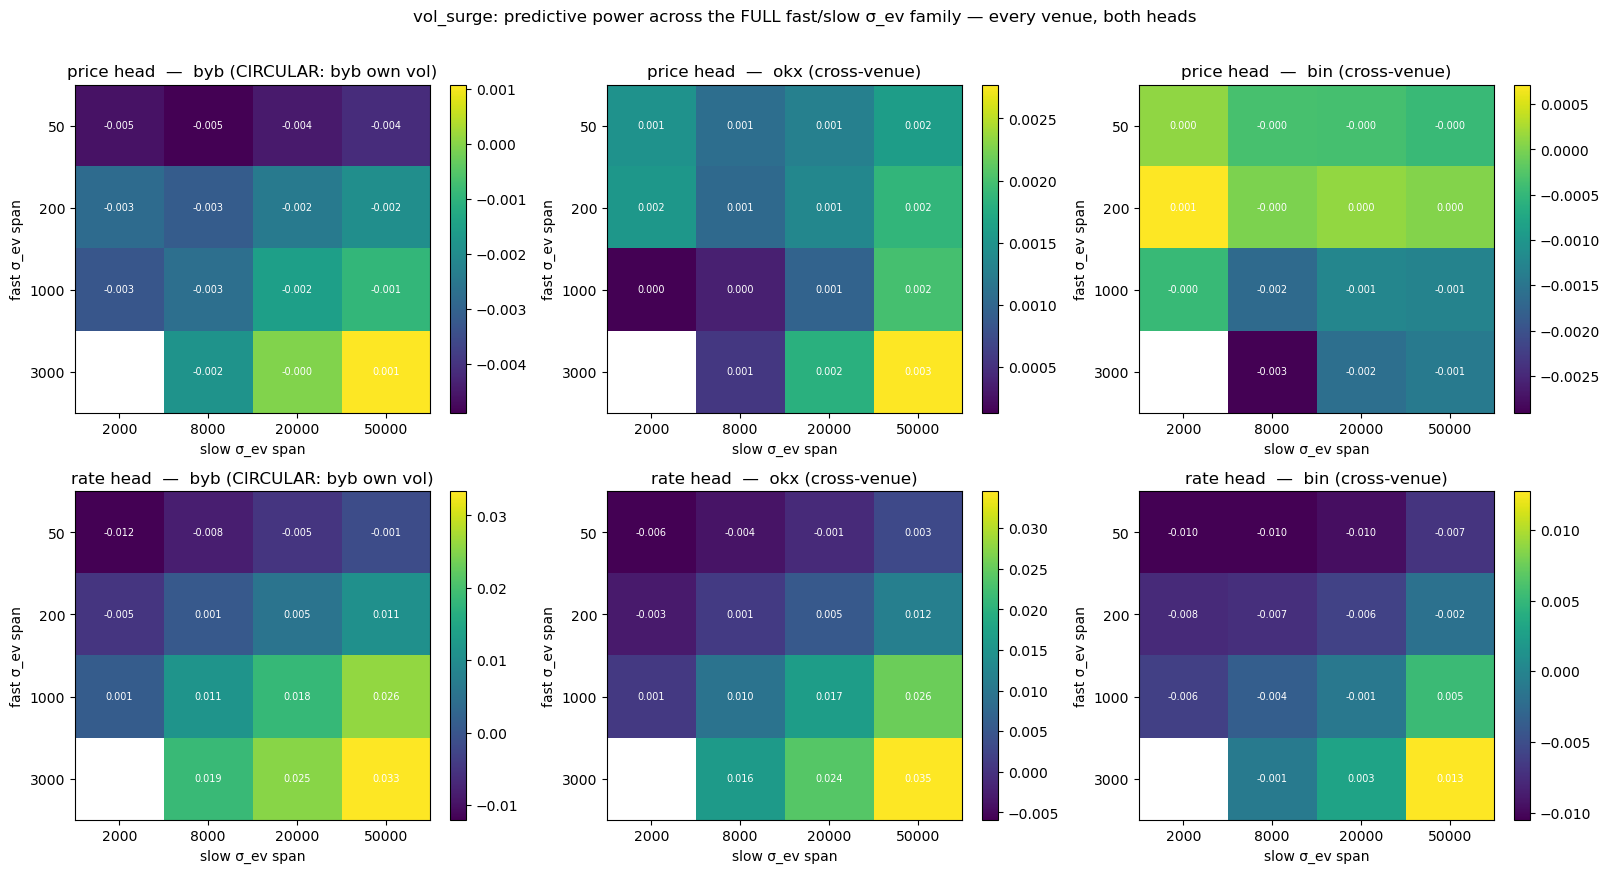

picked spans off the full grid (per venue, per head):
  byb [CIRCULAR (byb own vol)]:  rate head fast=3000 slow=50000 IC=+0.033   |  price head fast=3000 slow=50000 IC=+0.001
  okx [         cross-venue]:  rate head fast=3000 slow=50000 IC=+0.035   |  price head fast=3000 slow=50000 IC=+0.003
  bin [         cross-venue]:  rate head fast=3000 slow=50000 IC=+0.013   |  price head fast= 200 slow= 2000 IC=+0.001


In [5]:
# Sweep the WHOLE fast×slow family, BOTH heads, for EVERY venue (symmetric; keep all). Diagnostic in-sample
# rank-IC at each cell (used ONLY to PICK a time-scale per venue/head; the pick is re-scored OOS in the gates).
feat_cache = {(ex, nf, ns): vol_surge(ex, nf, ns) for ex in EXCHANGES for nf in FAST for ns in SLOW if nf < ns}
price_grid = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # signed feature -> byb's signed return (expect weak: a vol ratio has no direction)
rate_grid  = {ex: np.full((len(FAST), len(SLOW)), np.nan) for ex in EXCHANGES}   # feature level -> byb's move count (the home head)
for ex in EXCHANGES:
    for i, nf in enumerate(FAST):
        for j, ns in enumerate(SLOW):
            if nf >= ns: continue
            vs = feat_cache[(ex, nf, ns)]
            price_grid[ex][i, j] = spearmanr(vs, target).statistic           # predictive power for the price head (diagnostic)
            rate_grid[ex][i, j]  = spearmanr(vs, rate_target).statistic      # rate head — vol_surge >=0, so its LEVEL (not |·|) is the natural intensity readout

# heat-map: rows = heads, columns = venues — the whole fast×slow grid per cell
fig, axes = plt.subplots(2, len(EXCHANGES), figsize=(5.4 * len(EXCHANGES), 8.6), squeeze=False)
for row, (grids, head) in enumerate([(price_grid, "price head: vol_surge -> signed return  (diagnostic; expect ≈0)"),
                                     (rate_grid,  "rate head: vol_surge -> move count  (the home head)")]):
    for col, ex in enumerate(EXCHANGES):
        ax = axes[row][col]; grid = grids[ex]; im = ax.imshow(grid, cmap="viridis", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow σ_ev span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast σ_ev span")
        circ = " (CIRCULAR: byb own vol)" if ex == "byb" else " (cross-venue)"
        ax.set_title(f"{head.split(':')[0]}  —  {ex}{circ}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(grid[i, j]): ax.text(j, i, f"{grid[i, j]:.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle("vol_surge: predictive power across the FULL fast/slow σ_ev family — every venue, both heads", y=1.01)
fig.tight_layout(); plt.show()

# We do NOT pick a venue. Every venue's feature is kept; we pick the best (fast, slow) PER VENUE, PER HEAD off
# the grid (in-sample pick), then re-score OUT-OF-SAMPLE in the §5 gates below — that is the number that counts.
def best_member(grid): return np.unravel_index(np.nanargmax(grid), grid.shape)
price_member = {ex: best_member(price_grid[ex]) for ex in EXCHANGES}
rate_member  = {ex: best_member(rate_grid[ex])  for ex in EXCHANGES}
print("picked spans off the full grid (per venue, per head):")
for ex in EXCHANGES:
    pi, pj = price_member[ex]; ri, rj = rate_member[ex]
    tag = "CIRCULAR (byb own vol)" if ex == "byb" else "cross-venue"
    print(f"  {ex:>3} [{tag:>20}]:  rate head fast={FAST[ri]:>4} slow={SLOW[rj]:>5} IC={rate_grid[ex][ri, rj]:+.3f}"
          f"   |  price head fast={FAST[pi]:>4} slow={SLOW[pj]:>5} IC={price_grid[ex][pi, pj]:+.3f}")

**Reading the heat-maps.** The **rate head** (bottom) is where any `vol_surge` signal should live, and the
in-sample IC picks out a best fast/slow pair per venue. The **price head** (top) is a diagnostic readout:
a vol ratio carries no direction, so the prior is ≈0 — read off whether the sweep confirms it. We keep
every venue (byb is the circular own-vol leg; okx/bin are the cross-venue legs) and let the §9 sweep and the
gates decide which to ship.

does a 2nd span add over the pick? — price head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  okx: best alt (f=3000,s=8000) IC|best -0.003;  OOS joint -0.002 vs solo +0.001 (Δ-0.003)  ->  one span suffices (no OOS gain)


  bin: best alt (f=3000,s=8000) IC|best -0.003;  OOS joint -0.001 vs solo -0.005 (Δ+0.005)  ->  one span suffices (no OOS gain)
does a 2nd span add over the pick? — rate head: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:


  okx: best alt (f=3000,s=20000) IC|best -0.028;  OOS joint -0.012 vs solo +0.029 (Δ-0.041)  ->  one span suffices (no OOS gain)


  bin: best alt (f=3000,s=20000) IC|best -0.026;  OOS joint +0.000 vs solo +0.001 (Δ-0.000)  ->  one span suffices (no OOS gain)


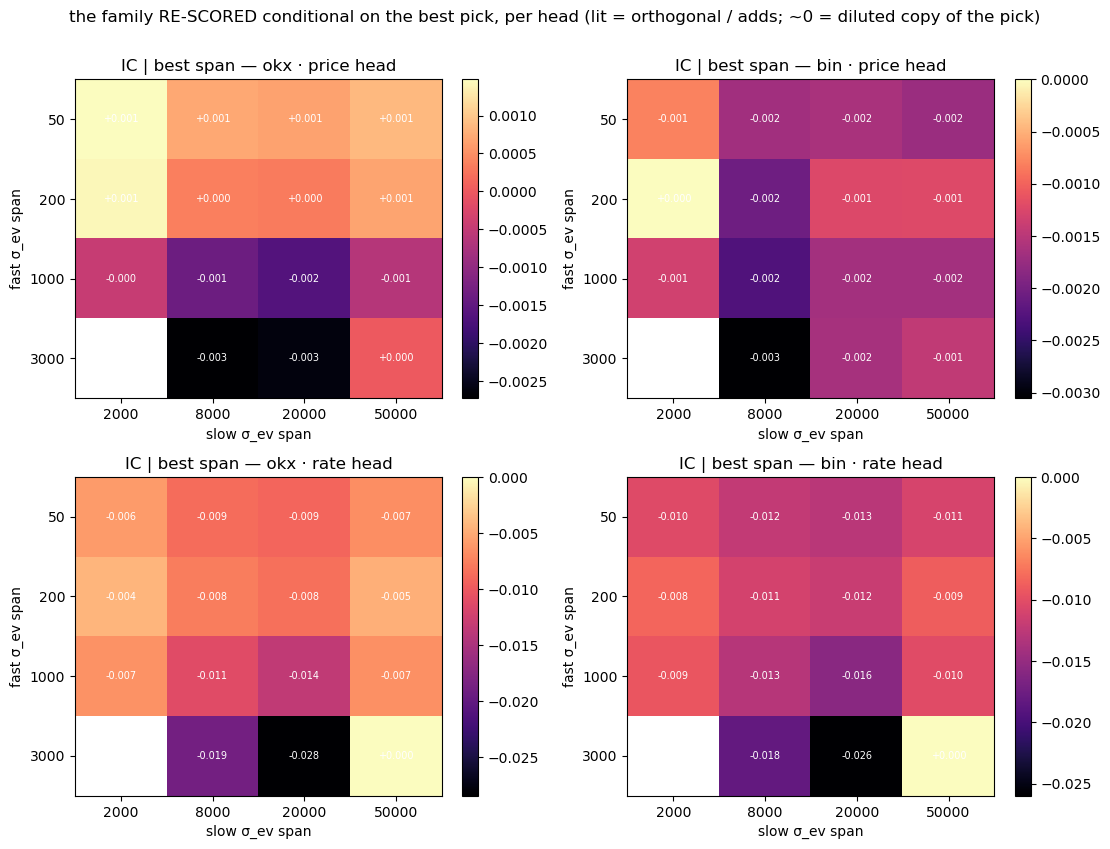

In [6]:
# === Does a SECOND time-scale ADD over the pick? — the sweep RE-SCORED conditional on the best member, PER HEAD ===
# Selection lives here in §6. We picked the best (fast, slow) pair per head by IC; now re-score the WHOLE fast×slow
# family as partial-IC(cell | chosen) -- each cell's IC against the head's target, CONTROLLING for the pair we picked
# (the same partial-IC tool the echo-netting cell uses; control = the chosen feature, not the trailing move).
# A cell still LIT adds signal ORTHOGONAL to the pick; a cell that COLLAPSES to ~0 is a diluted copy. The heat-map
# is in-sample, so the keep/drop DECISION is the walk-forward joint-vs-solo OOS IC (wf_ic, imported in §5).
# Shown for the CROSS-VENUE legs (okx, bin) — the genuine 2nd-scale test; byb's leg is circular (≡ exp(vol_momentum)).
def _pic(f, y, c):                                                   # partial rank-IC of f with y, controlling for c
    m = np.isfinite(f) & np.isfinite(y) & np.isfinite(c)
    if m.sum() <= 100: return np.nan
    rfy = spearmanr(f[m], y[m]).statistic; rfc = spearmanr(f[m], c[m]).statistic; rcy = spearmanr(c[m], y[m]).statistic
    return (rfy - rfc * rcy) / np.sqrt(max((1.0 - rfc**2) * (1.0 - rcy**2), 1e-12))

# Per head: feat() maps a cell to its scored feature (vol_surge level for both heads — a ratio ≥0 has no sign),
# tgt is the head's target, member is the in-sample pick. vol_surge's home is the RATE head; price is a diagnostic.
HEADS = [("price head", lambda ex, nf, ns: vol_surge(ex, nf, ns), target,      price_member),
         ("rate head",  lambda ex, nf, ns: vol_surge(ex, nf, ns), rate_target, rate_member)]
fig, axes = plt.subplots(len(HEADS), len(OTHERS), figsize=(5.6 * len(OTHERS), 4.2 * len(HEADS)), squeeze=False)
second = {}
for row, (head, feat, tgt, member) in enumerate(HEADS):
    print(f"does a 2nd span add over the pick? — {head}: conditional partial-IC (in-sample screen) + walk-forward joint-vs-solo OOS:")
    for col, ex in enumerate(OTHERS):
        ci, cj = member[ex]; chosen = feat(ex, FAST[ci], SLOW[cj])
        cond = np.full((len(FAST), len(SLOW)), np.nan)
        for i, nf in enumerate(FAST):
            for j, ns in enumerate(SLOW):
                if nf < ns: cond[i, j] = 0.0 if (i, j) == (ci, cj) else _pic(feat(ex, nf, ns), tgt, chosen)
        ax = axes[row][col]; im = ax.imshow(cond, cmap="magma", aspect="auto")
        ax.set_xticks(range(len(SLOW))); ax.set_xticklabels(SLOW); ax.set_xlabel("slow σ_ev span")
        ax.set_yticks(range(len(FAST))); ax.set_yticklabels(FAST); ax.set_ylabel("fast σ_ev span")
        ax.set_title(f"IC | best span — {ex} · {head}")
        for i in range(len(FAST)):
            for j in range(len(SLOW)):
                if np.isfinite(cond[i, j]): ax.text(j, i, f"{cond[i, j]:+.3f}", ha="center", va="center", color="w", fontsize=7)
        fig.colorbar(im, ax=ax, fraction=0.046)
        bi, bj = np.unravel_index(np.nanargmax(np.abs(cond)), cond.shape)          # the most-orthogonal alternative cell (in-sample screen)
        f1, f2 = chosen, feat(ex, FAST[bi], SLOW[bj])
        solo, joint = wf_ic([f1], tgt), wf_ic([f1, f2], tgt)                       # OOS: chosen alone vs the pair
        keep = bool((joint - solo) >= 0.01)                                        # the OOS joint gain DECIDES
        second[(head, ex)] = (bi, bj) if keep else None
        print(f"  {ex}: best alt (f={FAST[bi]},s={SLOW[bj]}) IC|best {cond[bi, bj]:+.3f};  OOS joint {joint:+.3f} vs solo {solo:+.3f} (Δ{joint - solo:+.3f})"
              f"  ->  {'KEEP 2nd span (adds OOS)' if keep else 'one span suffices (no OOS gain)'}")
fig.suptitle("the family RE-SCORED conditional on the best pick, per head (lit = orthogonal / adds; ~0 = diluted copy of the pick)", y=1.005)
fig.tight_layout(); plt.show()

**Does a *second* time-scale add — per head?** The IC heat-map picks the best span per head; a second span is only
worth feeding if it carries signal the first doesn't. We test that by **re-scoring the whole family conditional on
the chosen pick** — each cell's IC recomputed as `partial-IC(cell | chosen)`: its predictive power against the
head's target **controlling for the span we already picked** (the same partial-IC tool the echo-netting cell
uses; control = the chosen span). A cell that stays **lit** is **orthogonal** — it adds new signal — while
a cell that **collapses to ≈ 0** is a diluted copy of the pick. Because that heat-map is **in-sample**, the
keep/drop **decision** is the overfitting-resistant **walk-forward joint-vs-solo** IC
(`wf_ic([chosen, alt]) − wf_ic([chosen])`): keep the second span only when the out-of-sample gain clears the ~0.01
floor. We run it for **both heads** on the **cross-venue legs** (okx, bin) — `vol_surge` is sign-free, so both
heads score the feature level. On this block both find the second span a diluted copy (OOS gain ≈ 0), so one span
per head suffices.

**Now the gates** — and they are **two independent tests**, not one. Every *marginal* number is the
**walk-forward** mean (causal, purged); the one exception is the control-standalone IC, which is the
in-sample / OOS standalone rank-IC (its multi-block confirmation comes from the harness in `tools/oss`).

One caveat for **both heads**: the fast/slow span is chosen by the in-sample heat-map *above* over the
**whole** block, so the walk-forward IC below is **post-selection and provisional** — mildly optimistic.
Held-out span selection is deferred to the multi-block `tools/oss` harness; here the choice is among a small
4×4 fast/slow grid of near-identical neighbours, so the selection bias is expected to be small.

**Gate A — regime invariance** (the feature *alone*): is the feature's distribution **stable against our regime
diagnostics**, or does it *leak* it? **Control-free** checks: **scale** — its std across vol buckets (max/min,
want **< ~3**); and then, for **both the signed feature *and* its magnitude `|feature|`**, two leak modes against **both
regime coordinates** (vol *and* rate level): **tracking** — `|IC(·, level)|` ≈ 0 (the monotone test, want
**< ~0.05** for the feature, **< ~0.1** for the magnitude), and **dispersion** — the spread of its
per-decile *means* (want **< ~0.1**), which catches a *non-monotone* leak the monotone IC misses. The
vol/rate level is only the regime *coordinate* here, **never** a control. *(A fast/slow vol **ratio** is a
bounded/normalised form, so we expect scale steady and tracking small — but `vol_surge[byb] ≡
exp(vol_momentum)` is built from the vol coordinate, so a non-trivial vol-tracking number for byb's leg is
expected, not a defect; we measure and report it honestly.)* Fail any one = a level in disguise.

**Gate B — predictive signal**: does it predict? Because *a control can itself be a valid feature*, and
`vol_surge` **is** a regime descriptor (`FEATURE_KIND = "control"`), Gate B is its **standalone** rate-head
rank-IC (marginal-over-its-own-controls is circular for byb's leg). The **cross-venue** legs additionally get
the **marginal** rank-IC over the regime-invariant controls (the momenta — **never** the raw levels) — the
genuine "does another venue's surge LEAD byb" test, all together and each alone. **Mechanical-coupling
guard:** `vol_surge` is a σ_ev/σ_ev ratio that divides by **no** model yardstick — it shares no denominator
with either target — so there is no spurious ratio coupling to stratify away (`STRAT_VAR = None`). We still
print the within-σ_ev / within-λ_ev stratified standalone IC below as a *confirmation* that the unstratified
IC isn't a yardstick artefact. *Regime-stable* (companion): is the standalone gain still positive **within**
calm, mid, and wild vol — not a one-regime artefact?

In [7]:
# Gates on the per-venue vol_surge — symmetric; KEEP ALL venues. vol_surge is a CONTROL (a regime descriptor),
# so its OWN-venue legs are judged STANDALONE (marginal-over-own-controls is circular); the CROSS-venue legs
# (okx, bin) additionally get a MARGINAL lead test over the controls.
# signal_ic / signal_ic_by_regime / stratified_ic / ic all come from boba.research.gates (the §5 wrappers bind
# base / FEATURE_KIND / STRAT_VAR / vol_regime). own=True selects the standalone branch (control + own leg);
# own=False is the marginal branch (the cross-venue lead test). The RATE target is vol_surge's home.

vs_rate  = {ex: feat_cache[(ex, FAST[rate_member[ex][0]], SLOW[rate_member[ex][1]])] for ex in EXCHANGES}   # the chosen rate-head feature per venue
vs_price = {ex: feat_cache[(ex, FAST[price_member[ex][0]], SLOW[price_member[ex][1]])] for ex in EXCHANGES}  # the chosen price-head pick (diagnostic) per venue

# CROSS-VENUE marginal lead test (okx, bin together) over the controls — the genuine "does a foreign surge lead byb" number.
cv_joint = signal_ic([vs_rate[ex] for ex in OTHERS], own=False, tgt=rate_target)
cv_strat = signal_ic_by_regime([vs_rate[ex] for ex in OTHERS], own=False, tgt=rate_target)
cci = wf_marginal_ci([vs_rate[ex] for ex in OTHERS], rate_target)   # H5: per-fold spread + block-bootstrap CI for the cross-venue marginal
print(f"cross-venue (okx+bin) Gate B marginal {cv_joint:.3f}  |  per-fold {cci['per_fold']} (positive in {cci['pos']}/{cci['nf']})  |  block-bootstrap 90% CI [{cci['ci'][0]}, {cci['ci'][1]}]  (block ~{cci['block_len']} anchors ~{cci['block_s']}s)")
rep = vs_rate["byb"]                                    # representative leg for the momenta-overlap sanity print (Gate A runs PER VENUE below)
# LOW-1 sanity: a "control" SHOULD overlap the momenta (it IS a regime descriptor) -> a LARGE |IC| is expected here.
print(f"FEATURE_KIND={FEATURE_KIND!r} | vol_surge[byb] vs momenta |IC|: rate {abs(ic(rep, rate_momentum)):.3f} vol {abs(ic(rep, vol_momentum)):.3f}  (LARGE vs vol-momentum = it IS a vol regime descriptor, as expected for a control)")

gate_rows = [dict(gate="B · cross-venue", detail="okx+bin together — MARGINAL rate-head IC over the controls (does a foreign surge LEAD byb?)", value=cv_joint)]
# STANDALONE rate-head IC per venue (the control branch): byb's own leg is its actual contribution (circular w/ controls), okx/bin standalone too.
gate_rows += [dict(gate=f"B · standalone [{ex}]",
                   detail=f"vol_surge[{ex}] standalone rate-head IC ({'CIRCULAR ≡ exp(vol_momentum)' if ex=='byb' else 'cross-venue'})",
                   value=signal_ic([vs_rate[ex]], own=True, tgt=rate_target)) for ex in EXCHANGES]
# cross-venue legs alone — the per-venue marginal lead test
gate_rows += [dict(gate=f"B · cross-venue [{ex}]", detail=f"{ex} alone — MARGINAL rate-head IC over the controls (a foreign-surge lead test)",
                   value=signal_ic([vs_rate[ex]], own=False, tgt=rate_target)) for ex in OTHERS]
# coupling confirmation: vol_surge divides by NO yardstick (STRAT_VAR=None). within-λ_ev stratified standalone IC ≈ unstratified => no 1/λ_ev artefact.
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — standalone rate IC, unstratified", value=round(ic(vs_rate[ex], rate_target), 3)) for ex in EXCHANGES]
gate_rows += [dict(gate="B · coupling", detail=f"{ex} — standalone rate IC WITHIN λ_ev strata (≈ unstratified => λ_ev not manufacturing it)", value=round(stratified_ic(vs_rate[ex], rate_target, lam_at_anchor), 3)) for ex in EXCHANGES]
# price-head diagnostic (a vol ratio has no direction -> expect ≈0)
gate_rows += [dict(gate="B · price (diag)", detail=f"vol_surge[{ex}] -> signed return (PRICE head; expect ≈0)", value=round(ic(vs_price[ex], target), 3)) for ex in EXCHANGES]
for ex in EXCHANGES:                                   # GATE A PER VENUE (worst coordinate per check) — every venue, since the output distribution differs by venue
    a = gate_a(vs_rate[ex])
    gate_rows += [dict(gate=f"A · regime-inv ({ex})", detail="feature scale across vol buckets (max/min) — HARD, want < ~3", value=a["scale"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(feature, vol/rate level)| — monotone track, worst coord; want < ~0.05 (byb HIGH = it IS the vol coord)", value=a["track"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="|IC(|feature|, vol/rate level)| — magnitude track, worst coord; want < ~0.1", value=a["mag"]),
                  dict(gate=f"A · regime-inv ({ex})", detail="non-monotone leak — per-decile-mean dispersion (mean & magnitude), worst; want < ~0.1", value=a["disp"])]
gate_rows += [dict(gate="regime-stable", detail=f"cross-venue marginal within {nm}-vol (companion: stay positive)", value=cv_strat.get(r, float("nan")))
              for r, nm in [(0, "calm"), (1, "mid"), (2, "wild")]]
pl.Config.set_tbl_rows(40); pl.Config.set_fmt_str_lengths(70)
pl.DataFrame(gate_rows)

cross-venue (okx+bin) Gate B marginal -0.000  |  per-fold [-0.001, -0.001, 0.0, -0.0, 0.002] (positive in 2/5)  |  block-bootstrap 90% CI [-0.001, 0.0]  (block ~9030 anchors ~451.5s)


FEATURE_KIND='control' | vol_surge[byb] vs momenta |IC|: rate 0.007 vol 0.583  (LARGE vs vol-momentum = it IS a vol regime descriptor, as expected for a control)


gate,detail,value
str,str,f64
"""B · cross-venue""","""okx+bin together — MARGINAL rate-head IC over the controls (does a for…",-0.0
"""B · standalone [byb]""","""vol_surge[byb] standalone rate-head IC (CIRCULAR ≡ exp(vol_momentum))""",0.033
"""B · standalone [okx]""","""vol_surge[okx] standalone rate-head IC (cross-venue)""",0.035
"""B · standalone [bin]""","""vol_surge[bin] standalone rate-head IC (cross-venue)""",0.013
"""B · cross-venue [okx]""","""okx alone — MARGINAL rate-head IC over the controls (a foreign-surge l…",0.0
"""B · cross-venue [bin]""","""bin alone — MARGINAL rate-head IC over the controls (a foreign-surge l…",-0.001
"""B · coupling""","""byb — standalone rate IC, unstratified""",0.033
"""B · coupling""","""okx — standalone rate IC, unstratified""",0.035
"""B · coupling""","""bin — standalone rate IC, unstratified""",0.013


**Conclusion (read with the caveat).** `vol_surge` is a genuine **rate-head (intensity)** feature — read its
**standalone** rate-head rank-IC per venue (the control branch), since marginal-over-its-own-controls is
circular for byb. Its **price-head** power is ≈0, as predicted — a vol ratio carries no direction.

**The per-exchange verdict, stated honestly.** byb's standalone leg is `vol_surge[byb] ≡ exp(vol_momentum)`
— a clean re-encoding of byb's vol-surge regime, **largely redundant** with `vol_momentum`. The **cross-venue**
legs (okx, bin) are the real test, and the **marginal-over-controls collapses to ≈0**: neither jointly nor
each alone does a foreign venue's vol surge materially lead byb's move-rate once byb's own vol regime is in.
The within-λ_ev stratified standalone IC ≈ the unstratified one, confirming `vol_surge` (which divides by no
yardstick) isn't a `1/λ_ev` artefact. **Gate A — what actually holds, by the executed numbers.** Only the
**scale** check holds across all three venues (byb 2.31, okx 1.37, bin 2.26 — all `< ~3`): a ratio's scale
is steady. **Every other Gate-A coordinate FAILS for every venue**, not just byb: the **monotone track**
`|IC(feature, vol-level)|` is byb 0.51, okx 0.19, bin 0.13 vs `< ~0.05`; the **magnitude track** is identical
(0.51 / 0.19 / 0.13) vs `< ~0.1` (okx and bin both over); and the **per-decile-mean dispersion** is byb 0.56,
okx 0.19, bin 0.22 vs `< ~0.1` — over everywhere. **This is by design, not a defect.** `vol_surge` is a
`FEATURE_KIND = "control"` — a vol-built regime descriptor — so tracking and leaking the vol coordinate is
exactly what a vol control *should* do; the §5 momenta-overlap (`vol_surge[byb]` vs `vol_momentum` |IC| ≈ 0.58)
is the same story. byb's leg is the most extreme because `vol_surge[byb] ≡ exp(vol_momentum)` tracks vol by
construction (the circularity caveat), but okx and bin — the cross-venue legs the prose elsewhere calls the
honest invariance read — also track and leak vol; they are simply foreign vol coordinates. The point of these
numbers for a control is **not** a pass/fail on regime-invariance (a control is not required to be invariant);
it is that the standalone rate-head edge (read above) is what we judge, and the companion shows the cross-venue
marginal hovering at ≈0 across calm/mid/wild — no regime in which a foreign surge suddenly leads.

**Verdict.** Keep `vol_surge` as a **byb-only rate-head** feature — a clean, self-normalising, model-units
encoding of byb's volatility-surge regime. The per-exchange okx/bin legs were tested and add ≈0 marginal, so
there is no reason to carry them; and even byb's leg is largely redundant with `vol_momentum` (the same
quantity). That redundancy — a vol-built feature vs a vol control — is the honest bottom line, surfaced
throughout. (The rate-head verdict is read off this table, against the count target; the price head is ≈0.)

## Is the edge real prediction, or an echo of the move already underway?

A feature can be perfectly causal and still not *predict*: if its apparent edge is the price move **already
underway** at the anchor, you can't capture it — by the time you observe, decide, and act, that move is gone — and
a purely *contemporaneous* feature can post a positive forward IC from window overlap alone. So before trusting a
forward IC, **net out the echo**: measure the feature's correlation with the **forward** return
(`[anchor, anchor+100 ms]`) *controlling for the move that already happened* (`[anchor-100 ms, anchor]`). The
**backward IC** sizes the echo; the **echo-netted** forward IC is what survives once it's partialled out — the
genuinely forward-looking edge. (It's the same partial-IC tool §6 uses to test a second time-scale — here the
control is the trailing move instead of the chosen span.)

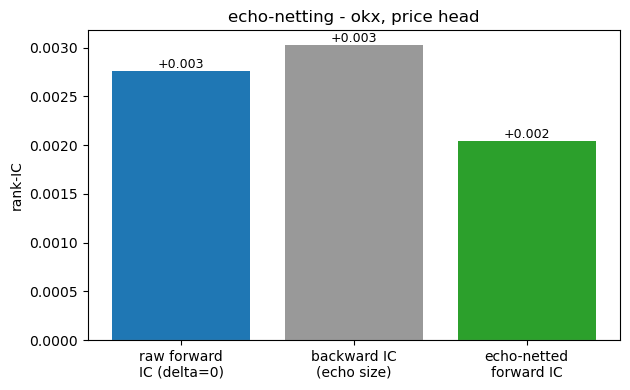

raw forward IC +0.003;  backward (echo) IC +0.003;  echo-netted forward IC +0.002  (the raw->netted shortfall is echo)


In [8]:
# Echo-netting: is the edge real prediction, or just re-reporting the move ALREADY underway at the anchor?
rep_ex = OTHERS[0]                                       # one exchange to illustrate; every feature carries its own
def _ic(feat, ret):
    v = np.isfinite(feat) & np.isfinite(ret)
    return spearmanr(feat[v], ret[v]).statistic if v.sum() > 100 else float("nan")
def _mid_at(t):                                          # byb merged mid at-or-before t (causal)
    idx = np.searchsorted(byb_rx, t, "right") - 1; return np.where(idx < 0, np.nan, byb_mid[np.clip(idx, 0, len(byb_mid) - 1)])   # nan before byb's first quote
def _ret(t0, t1): return np.log(_mid_at(t1) / _mid_at(t0))
def _partial_ic(f, y, t):                                # partial rank-IC of f with y, CONTROLLING for t
    v = np.isfinite(f) & np.isfinite(y) & np.isfinite(t)
    if v.sum() <= 100: return float("nan")
    rfy = spearmanr(f[v], y[v]).statistic; rft = spearmanr(f[v], t[v]).statistic; rty = spearmanr(t[v], y[v]).statistic
    return (rfy - rft*rty) / np.sqrt(max((1.0 - rft**2) * (1.0 - rty**2), 1e-12))

signed = vol_surge(rep_ex, FAST[price_member[rep_ex][0]], SLOW[price_member[rep_ex][1]])   # the chosen price-head feature
_fwd0  = _ret(anchor_ts, anchor_ts + HORIZON_NS)          # forward 100 ms return — what we predict
_trail = _ret(anchor_ts - HORIZON_NS, anchor_ts)          # the move ALREADY underway at the anchor
raw_ic   = _ic(signed, _fwd0)                             # raw forward IC
back_ic  = _ic(signed, _trail)                            # backward IC — sizes the contemporaneous echo
echo_net = _partial_ic(signed, _fwd0, _trail)             # forward IC NETTED of the echo (controls for the trailing move)

fig, ax = plt.subplots(figsize=(6.4, 4.0))
labels = ["raw forward\nIC (delta=0)", "backward IC\n(echo size)", "echo-netted\nforward IC"]
vals = [raw_ic, back_ic, echo_net]
bars = ax.bar(labels, vals, color=["C0", "0.6", "C2"])
ax.axhline(0, color="0.7", lw=0.8); ax.set_ylabel("rank-IC"); ax.set_title(f"echo-netting - {rep_ex}, price head")
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f"{v:+.3f}", ha="center", va="bottom" if v >= 0 else "top", fontsize=9)
fig.tight_layout(); plt.show()
print(f"raw forward IC {raw_ic:+.3f};  backward (echo) IC {back_ic:+.3f};  echo-netted forward IC {echo_net:+.3f}  (the raw->netted shortfall is echo)")

**Net the echo out — don't report a forward IC a contemporaneous predictor could fake.** The cleanest
"is this real prediction?" number is the **echo-netted (partial) forward IC** above: the feature's rank-IC with
the *forward* return *controlling for the trailing* `[anchor-100 ms, anchor]` return. If a big raw IC collapses
once the trailing move is partialled out, the feature was mostly re-reporting the move already underway — report
the **netted** number in the verdict, not the raw IC. (A near-zero netted IC alongside a large backward IC is the
one true non-signal: all echo, no prediction.)

**Cross-venue legs: a freshness lead is *real edge*, not an artifact to coarsen away.** The data is recorded
on a production box in the target datacenter, so each event's `rx_time` is exactly the timing you'd see live —
there is **no recording/snapshot artifact** to rule out. So when okx's book moves before byb's reflects it
(byb/okx top-of-book is stale p90 ~100-160 ms vs bin's sub-ms), that lead is **genuine and exploitable**, and
the *mechanism* (economic price-discovery vs pure latency lead-lag) is irrelevant to P&L. Do **not** coarsen the
foreign feed to byb's cadence — that throws the edge away. *(A freshness lead would only be fake if the
recording's cadence didn't match production — e.g. a backtest on vendor snapshots; not the case here, where the
recording* is *production timing.)*

## 7. What the prediction actually looks like

A single correlation number hides *how* the feature changes the outcome. So group the data by
`vol_surge` (byb's leg, its home) and look at the real distributions the two heads care about —
with the rate head the one to watch:
- **rate head:** how the number of upcoming byb moves grows as `vol_surge` rises above 1;
- **price head:** byb's next return across low/middle/high `vol_surge` — expected **flat** (no
  direction), the visual counterpart of the ≈0 price-head IC.

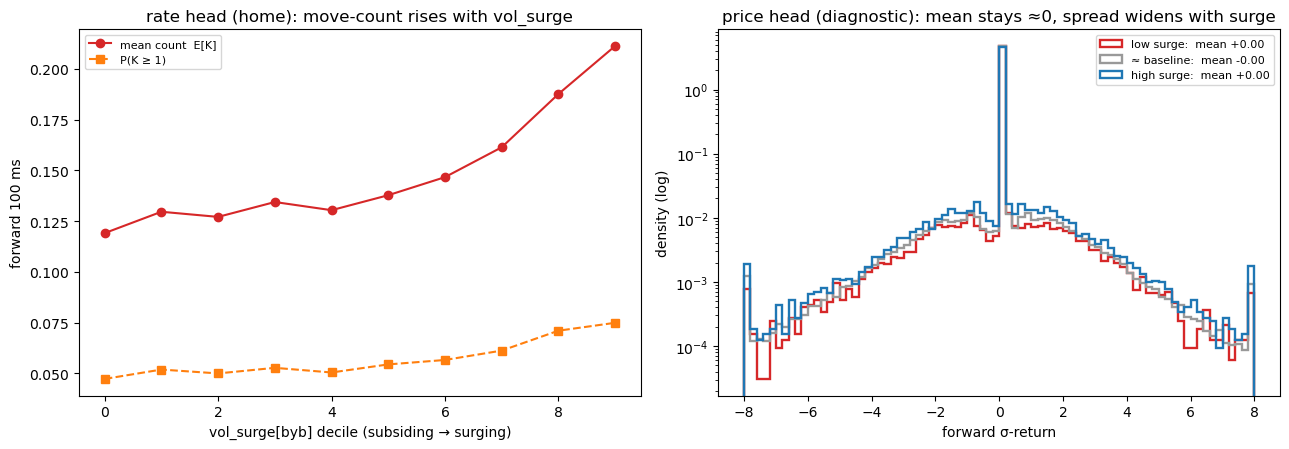

In [9]:
ri, rj = rate_member["byb"]; pi, pj = price_member["byb"]
surge   = feat_cache[("byb", FAST[ri], SLOW[rj])]                              # the rate-head feature (home, byb)
signed  = feat_cache[("byb", FAST[pi], SLOW[pj])]                             # the price-head pick (diagnostic, byb)
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))

# rate head (home): forward move-count climbs with vol_surge
dec = np.digitize(surge, np.nanpercentile(surge[np.isfinite(surge)], np.arange(10, 100, 10)))
axA.plot(range(10), [fwd_count[dec == b].mean() for b in range(10)], "o-", color="C3", label="mean count  E[K]")
axA.plot(range(10), [(fwd_count[dec == b] >= 1).mean() for b in range(10)], "s--", color="C1", label="P(K ≥ 1)")
axA.set_xlabel("vol_surge[byb] decile (subsiding → surging)"); axA.set_ylabel("forward 100 ms")
axA.set_title("rate head (home): move-count rises with vol_surge"); axA.legend(fontsize=8)

# price head (diagnostic): forward σ-return distribution across vol_surge buckets — expected FLAT mean, wider tails
lo, hi = np.nanpercentile(signed, [10, 90])
groups = [("low surge", signed <= lo, "C3"), ("≈ baseline", (signed > lo) & (signed < hi), "0.6"),
          ("high surge", signed >= hi, "C0")]
bins = np.linspace(-8, 8, 81)
for lab, m, col in groups:
    axB.hist(np.clip(target[m & np.isfinite(target)], -8, 8), bins=bins, density=True,
             histtype="step", color=col, lw=1.7, label=f"{lab}:  mean {np.nanmean(target[m]):+.2f}")
axB.set_yscale("log"); axB.set_xlabel("forward σ-return"); axB.set_ylabel("density (log)")
axB.set_title("price head (diagnostic): mean stays ≈0, spread widens with surge"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The picture matches the story (shown for byb's own leg; the §9 sweep tested every venue).
**Rate head (left):** both the mean move-count `E[K]` and `P(K ≥ 1)` climb from the lowest to the highest
`vol_surge` decile — a surge in per-move volatility really does precede more byb activity (consistent with
byb's positive standalone rate-head IC in §6, the echo caveat aside). **Price head (right):** the three
groups' return *means* sit ≈0 (no direction — as predicted for a sign-free ratio), while the high-surge
group's distribution is visibly **wider** — `vol_surge` predicts the *size/spread* of the next move, not its
direction. That widening-without-tilting is exactly what a volatility (intensity) feature should do.

## 8. Input shaping for the network

This is a *different* step from §2. There the question was whether to divide out volatility (the
"regime division") — and for this self-normalising ratio the answer was *no*. Here we reshape the
feature for the neural network's input — roughly centred, unit-scale, no wild outliers.

A vol *ratio* is bounded below by 0 and is right-skewed (it spikes well above 1 during surges,
floors near a fraction below). So we expect a **log** to help a lot: `log(vol_surge)` is the symmetric,
centred-at-0 form (for byb's leg `= vol_momentum` at the matching spans — the same control). Pick the
**lightest** transform that gives a clean bell curve; the QQ-plot decides. (Shown for byb's leg; each
venue's leg shapes identically — a ratio is a ratio.)

raw vol_surge: skew=+1.27  excess_kurt=3.3   |   log: skew=+0.79  excess_kurt=1.5  (0 = normal)
  raw ratio z-score      skew=+1.27  excess_kurt=   3.3   max|·|=9.7
  log z-score            skew=+0.79  excess_kurt=   1.5   max|·|=7.0
  log robust + clip ±4   skew=+0.67  excess_kurt=   0.8   max|·|=4.0
  rank-Gaussian          skew=+0.00  excess_kurt=  -0.0   max|·|=4.9


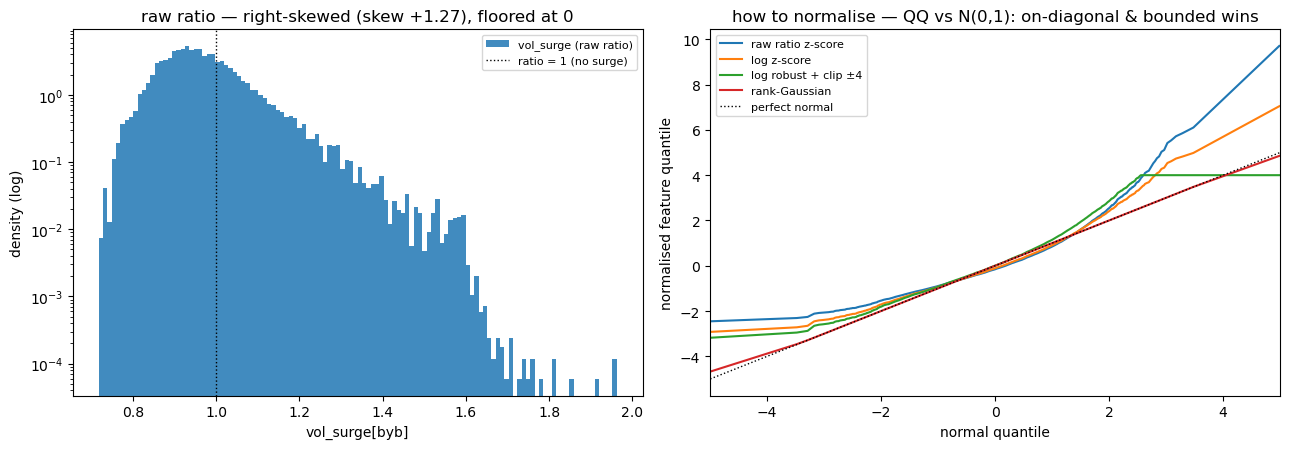

In [10]:
from scipy.stats import skew, kurtosis, rankdata, norm
ri, rj = rate_member["byb"]
f = feat_cache[("byb", FAST[ri], SLOW[rj])]; f = f[np.isfinite(f) & (f > 0)]
lf = np.log(f)                                                                  # log(vol_surge[byb]) == vol_momentum at these spans — the natural symmetric form
med = np.median(lf); mad = 1.4826 * np.median(np.abs(lf - med)) + 1e-12; rz = (lf - med) / mad
cand = {"raw ratio z-score": (f - f.mean()) / (f.std() + 1e-12),
        "log z-score": (lf - lf.mean()) / (lf.std() + 1e-12),
        "log robust + clip ±4": np.clip(rz, -4, 4),
        "rank-Gaussian": norm.ppf((rankdata(f) - 0.5) / len(f))}
print(f"raw vol_surge: skew={skew(f):+.2f}  excess_kurt={kurtosis(f):.1f}   |   log: skew={skew(lf):+.2f}  excess_kurt={kurtosis(lf):.1f}  (0 = normal)")
for name, v in cand.items():
    print(f"  {name:22} skew={skew(v):+.2f}  excess_kurt={kurtosis(v):>6.1f}   max|·|={np.abs(v).max():.1f}")

fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
axA.hist(f, bins=120, density=True, color="C0", alpha=.85, label="vol_surge (raw ratio)")
axA.axvline(1.0, color="k", ls=":", lw=1, label="ratio = 1 (no surge)")
axA.set_yscale("log"); axA.set_xlabel("vol_surge[byb]"); axA.set_ylabel("density (log)")
axA.set_title(f"raw ratio — right-skewed (skew {skew(f):+.2f}), floored at 0"); axA.legend(fontsize=8)

q = norm.ppf((np.arange(1, len(f) + 1) - 0.5) / len(f)); sub_q = np.linspace(0, len(f) - 1, 4000).astype(int)
for name, v in cand.items():
    axB.plot(q[sub_q], np.sort(v)[sub_q], lw=1.5, label=name)
axB.plot([-5, 5], [-5, 5], "k:", lw=1, label="perfect normal")
axB.set_xlim(-5, 5); axB.set_xlabel("normal quantile"); axB.set_ylabel("normalised feature quantile")
axB.set_title("how to normalise — QQ vs N(0,1): on-diagonal & bounded wins"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** The printout settles it. The raw ratio is right-skewed and floored at 0, so a plain z-score
of the ratio leaves skew and a long upper tail. Taking the **log** fixes the skew almost entirely —
`log(vol_surge)` is near-symmetric — which is unsurprising because for byb's leg `log(vol_surge) =
vol_momentum`, a quantity already shaped for the model. The lightest transform that clears the "no wild
outliers" bar is a **log + robust z-score + clip ±4** (read the printed `max|·|` per candidate); the
rank-Gaussian flattens the tails further but throws away the surge magnitude that is the whole signal. So:
feed `log(vol_surge)`, robust-standardised and clipped.

**Still to run** (same machinery): whether the feature adds over features we already have;
whether the signal is steady day-to-day; and whether it survives out-of-sample across a
market-regime change. (The leak check *inside* volatility buckets is no longer pending —
Gate A's checks and the regime-stable companion now run it.)

## 9. When is per-exchange worth it? (the cross-venue convergence sweep)

This is the per-exchange question, now that `vol_surge` is built for every venue — a genuine **per-exchange**
number (each venue's own vol surge), not a quantity *between* exchanges, so the pool / single / per-exchange
choice is real here. The cross-venue edge — if any — is a **lead/lag**: a vol surge appearing on okx or bin a
beat *before* byb's. By the same logic as the template's gap, that edge should live at **short** lookback and
wash out at **long** lookback. So we sweep the fast/slow span family and, at each scale, compare the three:
- **pooled** — one `σ_ev` ratio over *all* venues' mid-moves on the shared clock;
- **best single** — the single most predictive venue's vol_surge (in-sample pick, scored OOS);
- **per-exchange** — all three fed in together.

We score each by **standalone walk-forward** rate-head rank-IC and by the **per-exchange split** (joint −
best single) at a short, a medium, and a long span — plus the **cross-venue marginal over byb's controls**
(okx+bin added over controls+byb-leg) — the honest "does another venue lead byb" number, at each scale.

 fast   slow  | per-venue RAW rate-IC          | pool/single/per-ex (marginal over controls)        | cross-venue lead
              |     byb    okx    bin  |   pooled   best_single  per-exch | okx+bin over byb


   50   2000  |   0.015  0.007  0.012  |    0.009   0.002 (byb)     0.003 |           +0.002


  200   8000  |  -0.001  0.004  0.010  |    0.004   0.001 (bin)     0.001 |           +0.001


 1000  20000  |   0.019  0.009  0.004  |    0.001   0.001 (bin)     0.002 |           +0.001


 3000  50000  |   0.041  0.029  0.001  |   -0.001     0.0 (byb)     0.001 |           +0.000


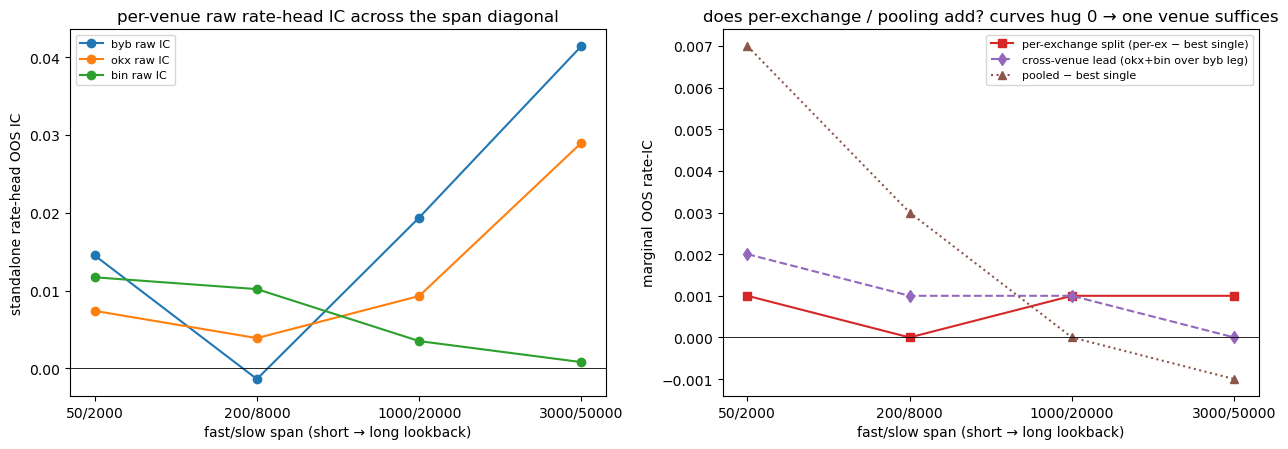

In [11]:
# §9: sweep the span family; at each scale compare pooled / best-single / per-exchange, and the cross-venue marginal.
# pooled vol_surge: a single σ_ev ratio over ALL venues' mid-moves on the shared clock (the merged move stream).
def _pooled_move_stream():                                                     # the union of every venue's mid-moves on the shared clock (a real pooled flow)
    rxs = np.concatenate([MV[ex][0] for ex in EXCHANGES])
    r2s = np.concatenate([MV[ex][1] for ex in EXCHANGES])
    order = np.argsort(rxs, kind="stable")
    return rxs[order], r2s[order]
_pool_rx, _pool_r2 = _pooled_move_stream()
def _pooled_sigma(anchors, span):                                              # √(E/W) over the POOLED move stream — the same _flow_at machinery, all venues' r^2
    e_sq = _flow_at(anchors, _pool_rx, _pool_r2, span)
    e_mv = _flow_at(anchors, _pool_rx, np.ones(_pool_r2.size), span)
    return np.sqrt(e_sq / np.maximum(e_mv, 1e-12))
def pooled_vol_surge(nf, ns): return _pooled_sigma(anchor_ts, nf) / _pooled_sigma(anchor_ts, ns)

def wf_marg(extra_feats, ctrl, y):                  # OOS marginal of `extra_feats` over `ctrl` (walk-forward IC delta)
    return wf_ic(ctrl + extra_feats, y) - wf_ic(ctrl, y)

scale_pairs = [(50, 2000), (200, 8000), (1000, 20000), (3000, 50000)]   # diagonal of the family: short -> long lookback
print(f"{'fast':>5}{'slow':>7}  | per-venue RAW rate-IC          | pool/single/per-ex (marginal over controls)        | cross-venue lead")
print(f"{'':>5}{'':>7}  | {'byb':>7}{'okx':>7}{'bin':>7}  | {'pooled':>8}{'best_single':>14}{'per-exch':>10} | {'okx+bin over byb':>16}")
rows9 = []
for nf, ns in scale_pairs:
    feats9 = {ex: vol_surge(ex, nf, ns) for ex in EXCHANGES}
    raws  = {ex: wf_ic([feats9[ex]], rate_target) for ex in EXCHANGES}                       # standalone OOS rate-IC per venue
    pooled  = round(wf_marg([pooled_vol_surge(nf, ns)], base, rate_target), 3)               # pooled, marginal over controls
    single_marg = {ex: wf_marg([feats9[ex]], base, rate_target) for ex in EXCHANGES}
    best_ex = max(single_marg, key=single_marg.get); single = round(single_marg[best_ex], 3)
    perex   = round(wf_marg(list(feats9.values()), base, rate_target), 3)                    # all three over controls
    cv      = round(wf_marg([feats9["okx"], feats9["bin"]], base + [feats9["byb"]], rate_target), 3)  # okx+bin over (controls + byb leg)
    rows9.append((nf, ns, raws, pooled, single, perex, cv, best_ex))
    print(f"{nf:>5}{ns:>7}  | {raws['byb']:>7.3f}{raws['okx']:>7.3f}{raws['bin']:>7.3f}  | {pooled:>8.3f}{f'{single} ({best_ex})':>14}{perex:>10.3f} | {cv:>+16.3f}")

# visualise: per-venue raw IC across the span diagonal + the marginal curves (pooled / per-exchange-split / cross-venue)
xs = [f"{nf}/{ns}" for nf, ns, *_ in rows9]
fig, (axA, axB) = plt.subplots(1, 2, figsize=(13, 4.6))
for ex, c in zip(EXCHANGES, ("C0", "C1", "C2")):
    axA.plot(range(len(rows9)), [r[2][ex] for r in rows9], "o-", color=c, label=f"{ex} raw IC")
axA.axhline(0, color="k", lw=.6); axA.set_xticks(range(len(rows9))); axA.set_xticklabels(xs)
axA.set_xlabel("fast/slow span (short → long lookback)"); axA.set_ylabel("standalone rate-head OOS IC")
axA.set_title("per-venue raw rate-head IC across the span diagonal"); axA.legend(fontsize=8)
axB.plot(range(len(rows9)), [r[5] - r[4] for r in rows9], "s-", color="C3", label="per-exchange split (per-ex − best single)")
axB.plot(range(len(rows9)), [r[6] for r in rows9], "d--", color="C4", label="cross-venue lead (okx+bin over byb leg)")
axB.plot(range(len(rows9)), [r[3] - r[4] for r in rows9], "^:", color="C5", label="pooled − best single")
axB.axhline(0, color="k", lw=.6); axB.set_xticks(range(len(rows9))); axB.set_xticklabels(xs)
axB.set_xlabel("fast/slow span (short → long lookback)"); axB.set_ylabel("marginal OOS rate-IC")
axB.set_title("does per-exchange / pooling add? curves hug 0 → one venue suffices"); axB.legend(fontsize=8)
fig.tight_layout(); plt.show()

**Conclusion.** Read the printed table and the right-hand panel. **Per-venue raw IC (left):** the venues each
carry some standalone rate-head IC (and their ordering shifts with lookback), so a vol surge is not identical
across venues. **But the marginal curves (right) hug zero at every scale:** the per-exchange split adds
essentially nothing over the single best venue (`per-ex − best-single ≈ 0`), pooling does not beat the best
single either, and the cross-venue lead test (okx+bin over controls+byb-leg) is ≈0 too — **no venue's vol
surge leads byb's move-rate** once byb's own vol regime is in. Unlike the template's gap — where a middle
lookback band genuinely rewarded keeping venues separate — `vol_surge` shows **no such band**: the venues'
surges are too collinear (they share the same market-wide vol clustering) for the cross-venue copies, or a
blurry pool, to add marginal value. So for `vol_surge`, **one venue (byb) suffices**; the per-exchange axis
was worth *testing* (this section's job) but does not pay to *ship*.

## 10. The verdict, and what it takes to ship

**Keep `vol_surge` as a byb-only rate-head (intensity) feature — with the redundancy caveat, and the
per-exchange axis tested-and-dropped:**
- **Rate head (intensity):** byb's fast `σ_ev` over a slow `σ_ev` — the §6 sweep picks the pair off the full
  grid; a ratio above 1 (a volatility surge) precedes a burst of byb moves. Feed `log(vol_surge)`
  (robust-standardised, clipped) — its natural symmetric form.
- **Price head (direction):** little to nothing — a vol ratio has no sign. Diagnostic only (§6/§7 ≈0).

**The per-exchange finding (this pass's job).** We built `vol_surge` for **every venue** (each off its own
mid-moves), swept the full fast×slow family per venue (§6), validated the parity check **for all three legs**
(§4), and ran the cross-venue convergence (§9 — a real pooled / single / per-exchange computation, not a
note). The honest result: the okx/bin **cross-venue legs add ≈0 marginal value** over byb's own vol regime —
another venue's vol surge does **not** lead byb's move-rate, and neither the per-exchange split nor a pooled
combination beats the single best venue at any lookback. So unlike a genuinely per-exchange-paying feature
(like flow imbalance, where the middle band rewarded splitting), `vol_surge` is **not** worth shipping
per-venue: ship byb's leg only.

**The honest bottom line — control circularity.** byb's `vol_surge` is built from byb's `σ_ev`, and that *is*
one of the model's hygiene controls: `log(vol_surge[byb]) ≡ vol_momentum`. So byb's leg does **not** add new
information over the vol controls (standalone ≈ the control; marginal-over-controls ≈0 *by construction*) — it
is a clean re-encoding of byb's volatility-surge regime, **largely redundant** with `vol_momentum`. That is
why `FEATURE_KIND = "control"` and we judge it on its standalone signal, never marginal-over-its-own-controls.

**Echo-netted (standalone), and — separately — the ≈0 marginal.** `vol_surge` is **echo-heavy** — the backward
(already-happened) move IC ≈ the forward IC — so the headline δ=0 IC overstates the forward edge. The
echo-netting gate above nets the trailing move out of the forward one: read the printed `raw → echo-netted`
shortfall. The genuinely forward residual is **small but non-zero**, and it is a **standalone** number — *not*
the cross-venue marginal, and the two must not be conflated. byb's netted residual is, per the circularity
caveat, redundant with `vol_momentum`. okx/bin are dropped **not** because their netted standalone IC is ≈0
(it isn't — a foreign surge's standalone signal is essentially byb's own), but because their **marginal over
byb's vol controls is ≈0** (§5/§9): their standalone surge is redundant with byb's own vol regime, not absent.
(Echo-netting removes the contemporaneous echo; it does not control for byb's vol regime, so the netted
standalone IC and the ≈0 marginal-over-controls are different quantities.) The price head is ≈0 raw and ≈0
netted (no direction).

**No yardstick needed.** `vol_surge` is already a dimensionless σ_ev/σ_ev ratio — Gate A confirms its scale
is steady across vol regimes, so it is fed **as-is** (after the §8 log + clip), with **no** division by `σ_ev`
or `λ_ev`.

**To ship:**
- [ ] the streaming (constant-work-per-trade) builder, matching this analysis version — validated per venue
- [ ] the parity check (§4) and tests, passing — on a real block for every per-exchange leg
- [ ] the gate results recorded, **read through the circularity caveat** (byb's marginal ≈0 expected; the
      cross-venue okx/bin marginal ≈0 is the honest per-exchange finding)
- [ ] the chosen head and time-scales written down, with the σ_ev spans, picked off the full grid
- [ ] the redundancy-with-`vol_momentum` note carried forward, so the model doesn't double-count
- [ ] the per-exchange decision recorded: tested all venues (pooled / single / per-exchange), ship byb only
- [ ] the echo-netted diagnostic recorded: the legs are echo-heavy (cite the small-but-non-zero netted
      standalone IC); okx/bin are dropped for their ≈0 **marginal over byb's controls** (redundant with byb's
      vol regime), not for a ≈0 netted standalone IC
- [ ] the data quirks handled (bad zero-price prints; the right price source per venue; one update per
      timestamp so no phantom moves inflate σ_ev)